# Notebook 3 - Pré-processamento para Clusterização

## 🎯 Objetivo
Preparar dataset final normalizado para clusterização de complexos cinematográficos:
- Aplicar regras de negócio validadas
- Resolver colinearidades
- Criar features compostas
- Normalizar e encodar variáveis
- Gerar artefatos para Notebook 4

## 📊 Input/Output
- **Input:** `df_complexos_features.parquet` (900 × 58)
- **Output:** `X_final_normalizado.npy` (~900 × 25-30)

---
## 1. Setup e Carregamento

### 1.1 Importações

In [1]:
# Manipulação de dados
import pandas as pd
import numpy as np
import json
import pickle
from datetime import datetime

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Configurações
import warnings
warnings.filterwarnings('ignore')

### 1.2 Configurações de Visualização

In [2]:
# Estilo seaborn
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Paletas customizadas (manter consistência com notebooks anteriores)
PALETA_CAT = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
PALETA_SUAVE = ['#a6cee3', '#1f78b4', '#b2df8a', '#33a02c']

### 1.3 Leitura do Dataset

In [3]:
# Carregar dataset de features
df = pd.read_parquet('../Bases/df_complexos_features.parquet')

# Backup para referência
df_original = df.copy()

print(f"✓ Dataset carregado: {df.shape}")
print(f"  - {df.shape[0]} complexos")
print(f"  - {df.shape[1]} colunas")

✓ Dataset carregado: (900, 58)
  - 900 complexos
  - 58 colunas


### 1.4 Resumo Inicial

In [4]:
print("=" * 80)
print("RESUMO DO DATASET")
print("=" * 80)

# Dimensões
print(f"\n📊 Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas")

# Identificadores vs Features Geográficas
print(f"\n🔑 Identificador Único:")
print(f"  - REGISTRO_COMPLEXO: {df['REGISTRO_COMPLEXO'].nunique()} únicos")
print(f"    → Será EXCLUÍDO da matriz de features (apenas ID)")

print(f"\n🌍 Features Geográficas:")
if 'UF' in df.columns:
    print(f"  - UF: {df['UF'].nunique()} estados")
    print(f"    → Será ONE-HOT ENCODED (feature categórica)")
if 'municipio' in df.columns:
    print(f"  - municipio: {df['municipio'].nunique()} municípios")
    print(f"    → ⚠️ DECISÃO NECESSÁRIA: 449 categorias podem causar overfitting")
    print(f"       Alternativa: usar 'porte_municipio_cat' (5 categorias)")

# Tipos de dados
print(f"\n💾 Tipos de Dados:")
dtype_map = {
    'int64': 0,
    'float64': 0,
    'object': 0,
    'category': 0
}

for dtype in df.dtypes:
    dtype_str = str(dtype)
    if 'int' in dtype_str:
        dtype_map['int64'] += 1
    elif 'float' in dtype_str:
        dtype_map['float64'] += 1
    elif 'object' in dtype_str:
        dtype_map['object'] += 1
    elif 'category' in dtype_str:
        dtype_map['category'] += 1

for dtype, count in dtype_map.items():
    if count > 0:
        print(f"  - {dtype}: {count} colunas")

# Detalhar categóricas
cat_cols = df.select_dtypes(include=['category']).columns.tolist()
if cat_cols:
    print(f"\n  📋 Categóricas (serão one-hot encoded):")
    for col in cat_cols:
        n_cats = df[col].nunique()
        print(f"     • {col}: {n_cats} categorias")

# Valores nulos
print(f"\n⚠️ Valores Nulos:")
nulls = df.isnull().sum()
nulls = nulls[nulls > 0]

if len(nulls) > 0:
    for col, count in nulls.items():
        pct = count / len(df) * 100
        print(f"  - {col}: {count} ({pct:.1f}%)")
    
    print(f"\n  💡 Interpretação:")
    if 'produtora_nivel_medio_complexo' in nulls.index:
        print(f"     • produtora_nivel_medio_complexo:")
        print(f"       - Complexos sem filmes brasileiros com produtora identificada")
        print(f"       - Será imputado com ZERO (ausência de produtora = nível zero)")
else:
    print("  ✓ Nenhum valor nulo detectado")

# Resumo
print(f"\n📈 Resumo:")
numeric_cols = df.select_dtypes(include=[np.number]).columns
id_cols = ['REGISTRO_COMPLEXO']
geo_cols = [c for c in ['UF', 'municipio'] if c in df.columns]
print(f"  - Features numéricas: {len([c for c in numeric_cols if c not in id_cols])}")
print(f"  - Features categóricas: {len(cat_cols)}")
print(f"  - Features geográficas (texto): {len(geo_cols)}")
print(f"  - Identificadores: {len(id_cols)}")

print("\n" + "=" * 80)


RESUMO DO DATASET

📊 Dimensões: 900 linhas × 58 colunas

🔑 Identificador Único:
  - REGISTRO_COMPLEXO: 900 únicos
    → Será EXCLUÍDO da matriz de features (apenas ID)

🌍 Features Geográficas:
  - UF: 27 estados
    → Será ONE-HOT ENCODED (feature categórica)
  - municipio: 449 municípios
    → ⚠️ DECISÃO NECESSÁRIA: 449 categorias podem causar overfitting
       Alternativa: usar 'porte_municipio_cat' (5 categorias)

💾 Tipos de Dados:
  - int64: 20 colunas
  - float64: 33 colunas
  - object: 3 colunas
  - category: 2 colunas

  📋 Categóricas (serão one-hot encoded):
     • porte_municipio_cat: 5 categorias
     • faixa_renda_cat: 4 categorias

⚠️ Valores Nulos:
  - produtora_nivel_medio_complexo: 7 (0.8%)

  💡 Interpretação:
     • produtora_nivel_medio_complexo:
       - Complexos sem filmes brasileiros com produtora identificada
       - Será imputado com ZERO (ausência de produtora = nível zero)

📈 Resumo:
  - Features numéricas: 53
  - Features categóricas: 2
  - Features geográfi

---
## 2. Diagnóstico Completo

### 2.1 Análise de Valores Nulos

In [5]:
# Verificação detalhada de nulls
null_summary = pd.DataFrame({
    'Nulls': df.isnull().sum(),
    'Pct': (df.isnull().sum() / len(df) * 100).round(2)
})
null_summary = null_summary[null_summary['Nulls'] > 0].sort_values('Nulls', ascending=False)

if len(null_summary) > 0:
    print("⚠️ ATENÇÃO: Valores nulos detectados:")
    print(null_summary)
    print("   → produtora_nivel_medio_complexo: Imputar com ZERO")
    print("   → Motivo: Ausência de produtora identificada = nível zero")
    print("   → Aplicação: Será executada antes da normalização (Seção 6)")
else:
    print("✓ Nenhum valor nulo - Dataset completo")

⚠️ ATENÇÃO: Valores nulos detectados:
                                Nulls   Pct
produtora_nivel_medio_complexo      7  0.78
   → produtora_nivel_medio_complexo: Imputar com ZERO
   → Motivo: Ausência de produtora identificada = nível zero
   → Aplicação: Será executada antes da normalização (Seção 6)


In [6]:
# Aplicar imputação
print("\n🔧 APLICANDO IMPUTAÇÃO:")
if 'produtora_nivel_medio_complexo' in df.columns:
    n_nulls_antes = df['produtora_nivel_medio_complexo'].isnull().sum()
    df['produtora_nivel_medio_complexo'].fillna(0, inplace=True)
    n_nulls_depois = df['produtora_nivel_medio_complexo'].isnull().sum()
    
    print(f"   ✓ produtora_nivel_medio_complexo:")
    print(f"     - Antes: {n_nulls_antes} nulos")
    print(f"     - Depois: {n_nulls_depois} nulos")
    print(f"     - Valor imputado: 0 (ausência de produtora)")

print("\n✓ Imputação concluída - Dataset sem valores nulos")


🔧 APLICANDO IMPUTAÇÃO:
   ✓ produtora_nivel_medio_complexo:
     - Antes: 7 nulos
     - Depois: 0 nulos
     - Valor imputado: 0 (ausência de produtora)

✓ Imputação concluída - Dataset sem valores nulos


### 2.2 Análise de Variância

In [7]:
# Calcular variância para features numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Remover identificadores
id_cols_to_exclude = ['REGISTRO_COMPLEXO']
numeric_cols = [col for col in numeric_cols if col not in id_cols_to_exclude]

variance_df = pd.DataFrame({
    'Feature': numeric_cols,
    'Variance': [df[col].var() for col in numeric_cols]
}).sort_values('Variance', ascending=True)

print("=" * 80)
print("FEATURES COM BAIXA VARIÂNCIA (< 0.01)")
print("=" * 80)
low_var = variance_df[variance_df['Variance'] < 0.01]
if len(low_var) > 0:
    print(low_var.to_string(index=False))
    print(f"\nTotal: {len(low_var)} features com variância < 0.01")
else:
    print("✓ Nenhuma feature com variância < 0.01")

print("\n" + "=" * 80)
print("FEATURES COM VARIÂNCIA MUITO BAIXA (< 0.001)")
print("=" * 80)
very_low_var = variance_df[variance_df['Variance'] < 0.001]
if len(very_low_var) > 0:
    print(very_low_var.to_string(index=False))
else:
    print("✓ Nenhuma feature com variância < 0.001")

FEATURES COM BAIXA VARIÂNCIA (< 0.01)
                              Feature  Variance
                     tem_distribuidor  0.000000
                     pct_modalidade_b  0.000201
                 pct_obras_exclusivas  0.000297
                     pct_modalidade_c  0.000360
                 pct_obras_ultranicho  0.000374
                     pct_modalidade_d  0.001679
                pct_sessoes_especiais  0.002096
                     pct_modalidade_a  0.002278
         pct_sessoes_com_distribuidor  0.002561
     pct_sessoes_distrib_independente  0.002811
                     natureza_publica  0.004430
               operacao_nao_comercial  0.004430
pct_sessoes_brasileiras_independentes  0.004729
   pct_sessoes_produtora_independente  0.004729
             pct_obras_cinema_mundial  0.005805

Total: 15 features com variância < 0.01

FEATURES COM VARIÂNCIA MUITO BAIXA (< 0.001)
             Feature  Variance
    tem_distribuidor  0.000000
    pct_modalidade_b  0.000201
pct_obras_excl

In [8]:
print("\n" + "="*80)
print("DECISÕES SOBRE FEATURES COM BAIXA VARIÂNCIA")
print("="*80)

print("\n❌ REMOVER:")
print("   • tem_distribuidor (var=0.000)")
print("     - Todos complexos = 1 (não discrimina)")
print("     - Redundante com pct_sessoes_com_distribuidor")

print("\n✅ MANTER (apesar de baixa variância):")
print("   • pct_modalidade_b/c/d:")
print("     - Obrigatórias (Art. 6º ANCINE)")
print("     - Identificam cumprimento de cotas")
print("   • pct_obras_exclusivas/ultranicho:")
print("     - Discriminam segmento de curadoria especializada")
print("     - Poucos complexos, mas alta relevância")
print("   • operacao_nao_comercial:")
print("     - Identifica cinemas públicos/gratuitos")
print("     - Segmento regulatório específico")
print("   • pct_sessoes_especiais:")
print("     - Obrigatória (Art. 6º)")
print("     - Sessões fora de circuito comercial")

print("\n💡 PRINCÍPIO:")
print("   Baixa variância ≠ remoção automática")
print("   Decisão baseada em: relevância teórica + significado regulatório")
print("="*80)


DECISÕES SOBRE FEATURES COM BAIXA VARIÂNCIA

❌ REMOVER:
   • tem_distribuidor (var=0.000)
     - Todos complexos = 1 (não discrimina)
     - Redundante com pct_sessoes_com_distribuidor

✅ MANTER (apesar de baixa variância):
   • pct_modalidade_b/c/d:
     - Obrigatórias (Art. 6º ANCINE)
     - Identificam cumprimento de cotas
   • pct_obras_exclusivas/ultranicho:
     - Discriminam segmento de curadoria especializada
     - Poucos complexos, mas alta relevância
   • operacao_nao_comercial:
     - Identifica cinemas públicos/gratuitos
     - Segmento regulatório específico
   • pct_sessoes_especiais:
     - Obrigatória (Art. 6º)
     - Sessões fora de circuito comercial

💡 PRINCÍPIO:
   Baixa variância ≠ remoção automática
   Decisão baseada em: relevância teórica + significado regulatório


### 2.3 Matriz de Correlação

**Objetivo:** Identificar pares de features altamente correlacionadas (|r| > 0.85)

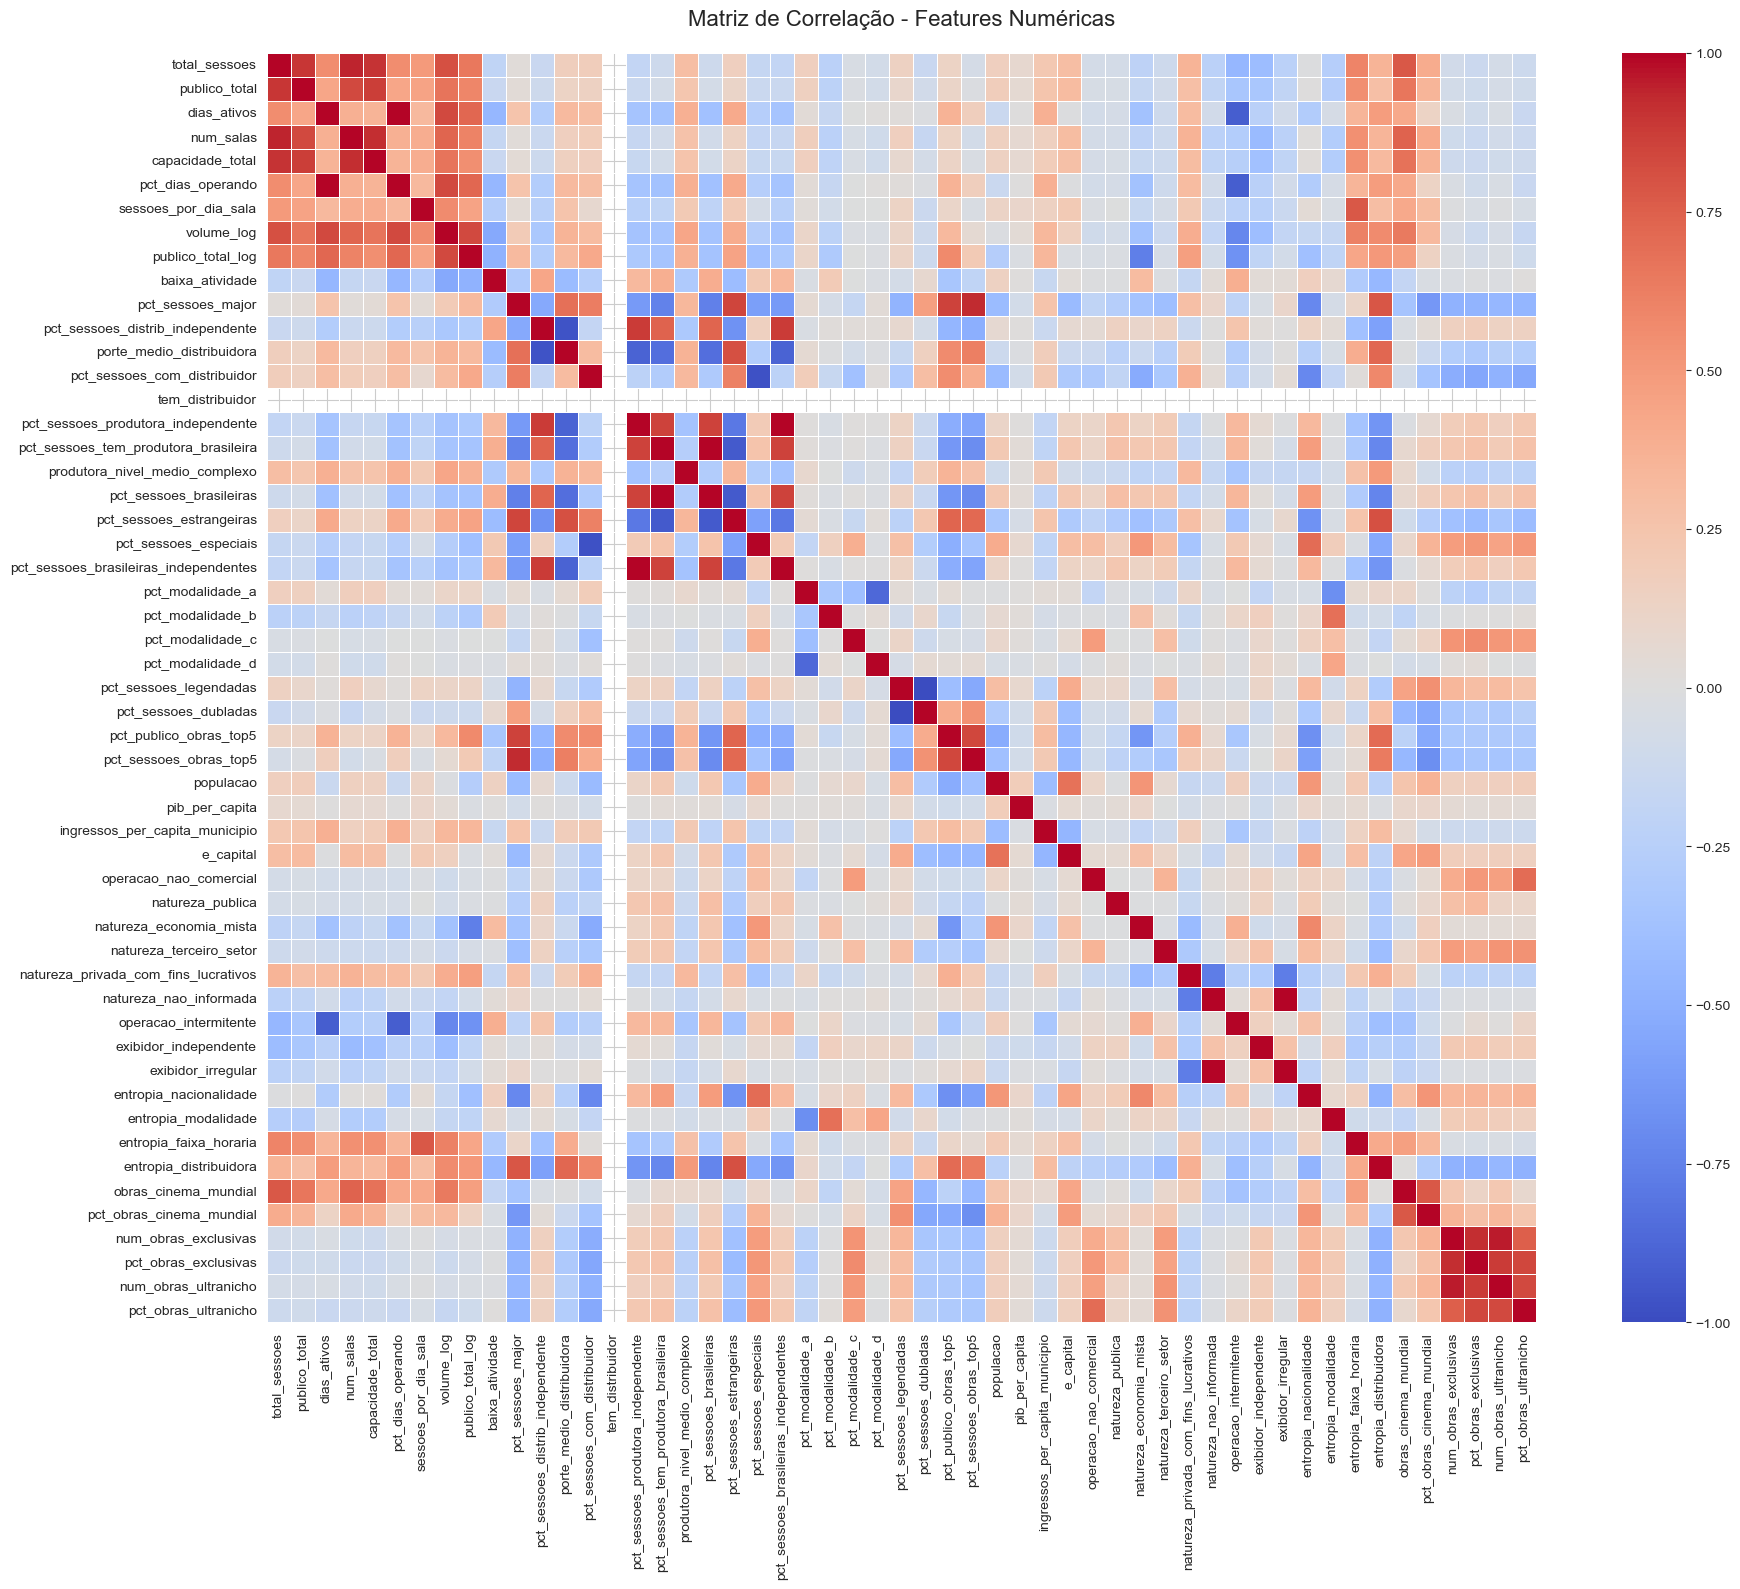

✓ Matriz de correlação salva em: ../Outputs/correlacao_features.png


In [9]:
# Calcular matriz de correlação
corr_matrix = df[numeric_cols].corr()

# Visualizar matriz completa
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, 
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Matriz de Correlação - Features Numéricas', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig('../Outputs/correlacao_features.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Matriz de correlação salva em: ../Outputs/correlacao_features.png")

In [10]:
print("\n" + "="*80)
print("ANÁLISE CRÍTICA DA MATRIZ")
print("="*80)

print("\n🚨 COLINEARIDADE PERFEITA DETECTADA (|r| > 0.95):")
print("   1. pct_sessoes_brasileiras_independentes ↔ pct_sessoes_produtora_independente")
print("   2. pct_sessoes_tem_produtora_brasileira ↔ pct_sessoes_brasileiras")
print("   3. pct_dias_operando ↔ dias_ativos")
print("   4. num_obras_exclusivas ↔ pct_obras_exclusivas ↔ num_obras_ultranicho")
print("   5. pct_modalidade_a/b/c/d (somam 100%)")

print("\n✅ CORRELAÇÕES ESPERADAS (features compostas):")
print("   • dependencia_blockbuster ↔ pct_publico_obras_top5 (r≈0.98)")
print("   • pct_obras_nao_anglo ↔ pct_sessoes_brasileiras (r≈0.84)")

print("\n💡 DECISÃO:")
print("   → Remover features redundantes na Seção 3.2")
print("   → Manter features compostas (capturam relações relevantes)")
print("="*80)


ANÁLISE CRÍTICA DA MATRIZ

🚨 COLINEARIDADE PERFEITA DETECTADA (|r| > 0.95):
   1. pct_sessoes_brasileiras_independentes ↔ pct_sessoes_produtora_independente
   2. pct_sessoes_tem_produtora_brasileira ↔ pct_sessoes_brasileiras
   3. pct_dias_operando ↔ dias_ativos
   4. num_obras_exclusivas ↔ pct_obras_exclusivas ↔ num_obras_ultranicho
   5. pct_modalidade_a/b/c/d (somam 100%)

✅ CORRELAÇÕES ESPERADAS (features compostas):
   • dependencia_blockbuster ↔ pct_publico_obras_top5 (r≈0.98)
   • pct_obras_nao_anglo ↔ pct_sessoes_brasileiras (r≈0.84)

💡 DECISÃO:
   → Remover features redundantes na Seção 3.2
   → Manter features compostas (capturam relações relevantes)


In [11]:
# Identificar pares com alta correlação
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.85:
            high_corr_pairs.append({
                'Feature_1': corr_matrix.columns[i],
                'Feature_2': corr_matrix.columns[j],
                'Correlacao': corr_val
            })

if len(high_corr_pairs) > 0:
    print("=" * 80)
    print("PARES COM CORRELAÇÃO |r| > 0.85")
    print("=" * 80)
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlacao', 
                                                              key=abs, 
                                                              ascending=False)
    print(high_corr_df.to_string(index=False))
    print(f"\nTotal: {len(high_corr_pairs)} pares altamente correlacionados")
else:
    print("✓ Nenhum par com correlação |r| > 0.85")

PARES COM CORRELAÇÃO |r| > 0.85
                           Feature_1                             Feature_2  Correlacao
              natureza_nao_informada                    exibidor_irregular    1.000000
  pct_sessoes_produtora_independente pct_sessoes_brasileiras_independentes    1.000000
                         dias_ativos                     pct_dias_operando    1.000000
              pct_sessoes_legendadas                  pct_sessoes_dubladas   -1.000000
pct_sessoes_tem_produtora_brasileira               pct_sessoes_brasileiras    0.996718
        pct_sessoes_com_distribuidor                 pct_sessoes_especiais   -0.976470
    pct_sessoes_distrib_independente             porte_medio_distribuidora   -0.963258
                num_obras_exclusivas                  num_obras_ultranicho    0.956040
                       total_sessoes                             num_salas    0.938081
             pct_sessoes_brasileiras              pct_sessoes_estrangeiras   -0.934970
pct_sessoes

### 2.4 Distribuição de Features

**Grid de histogramas para análise visual de distribuições**

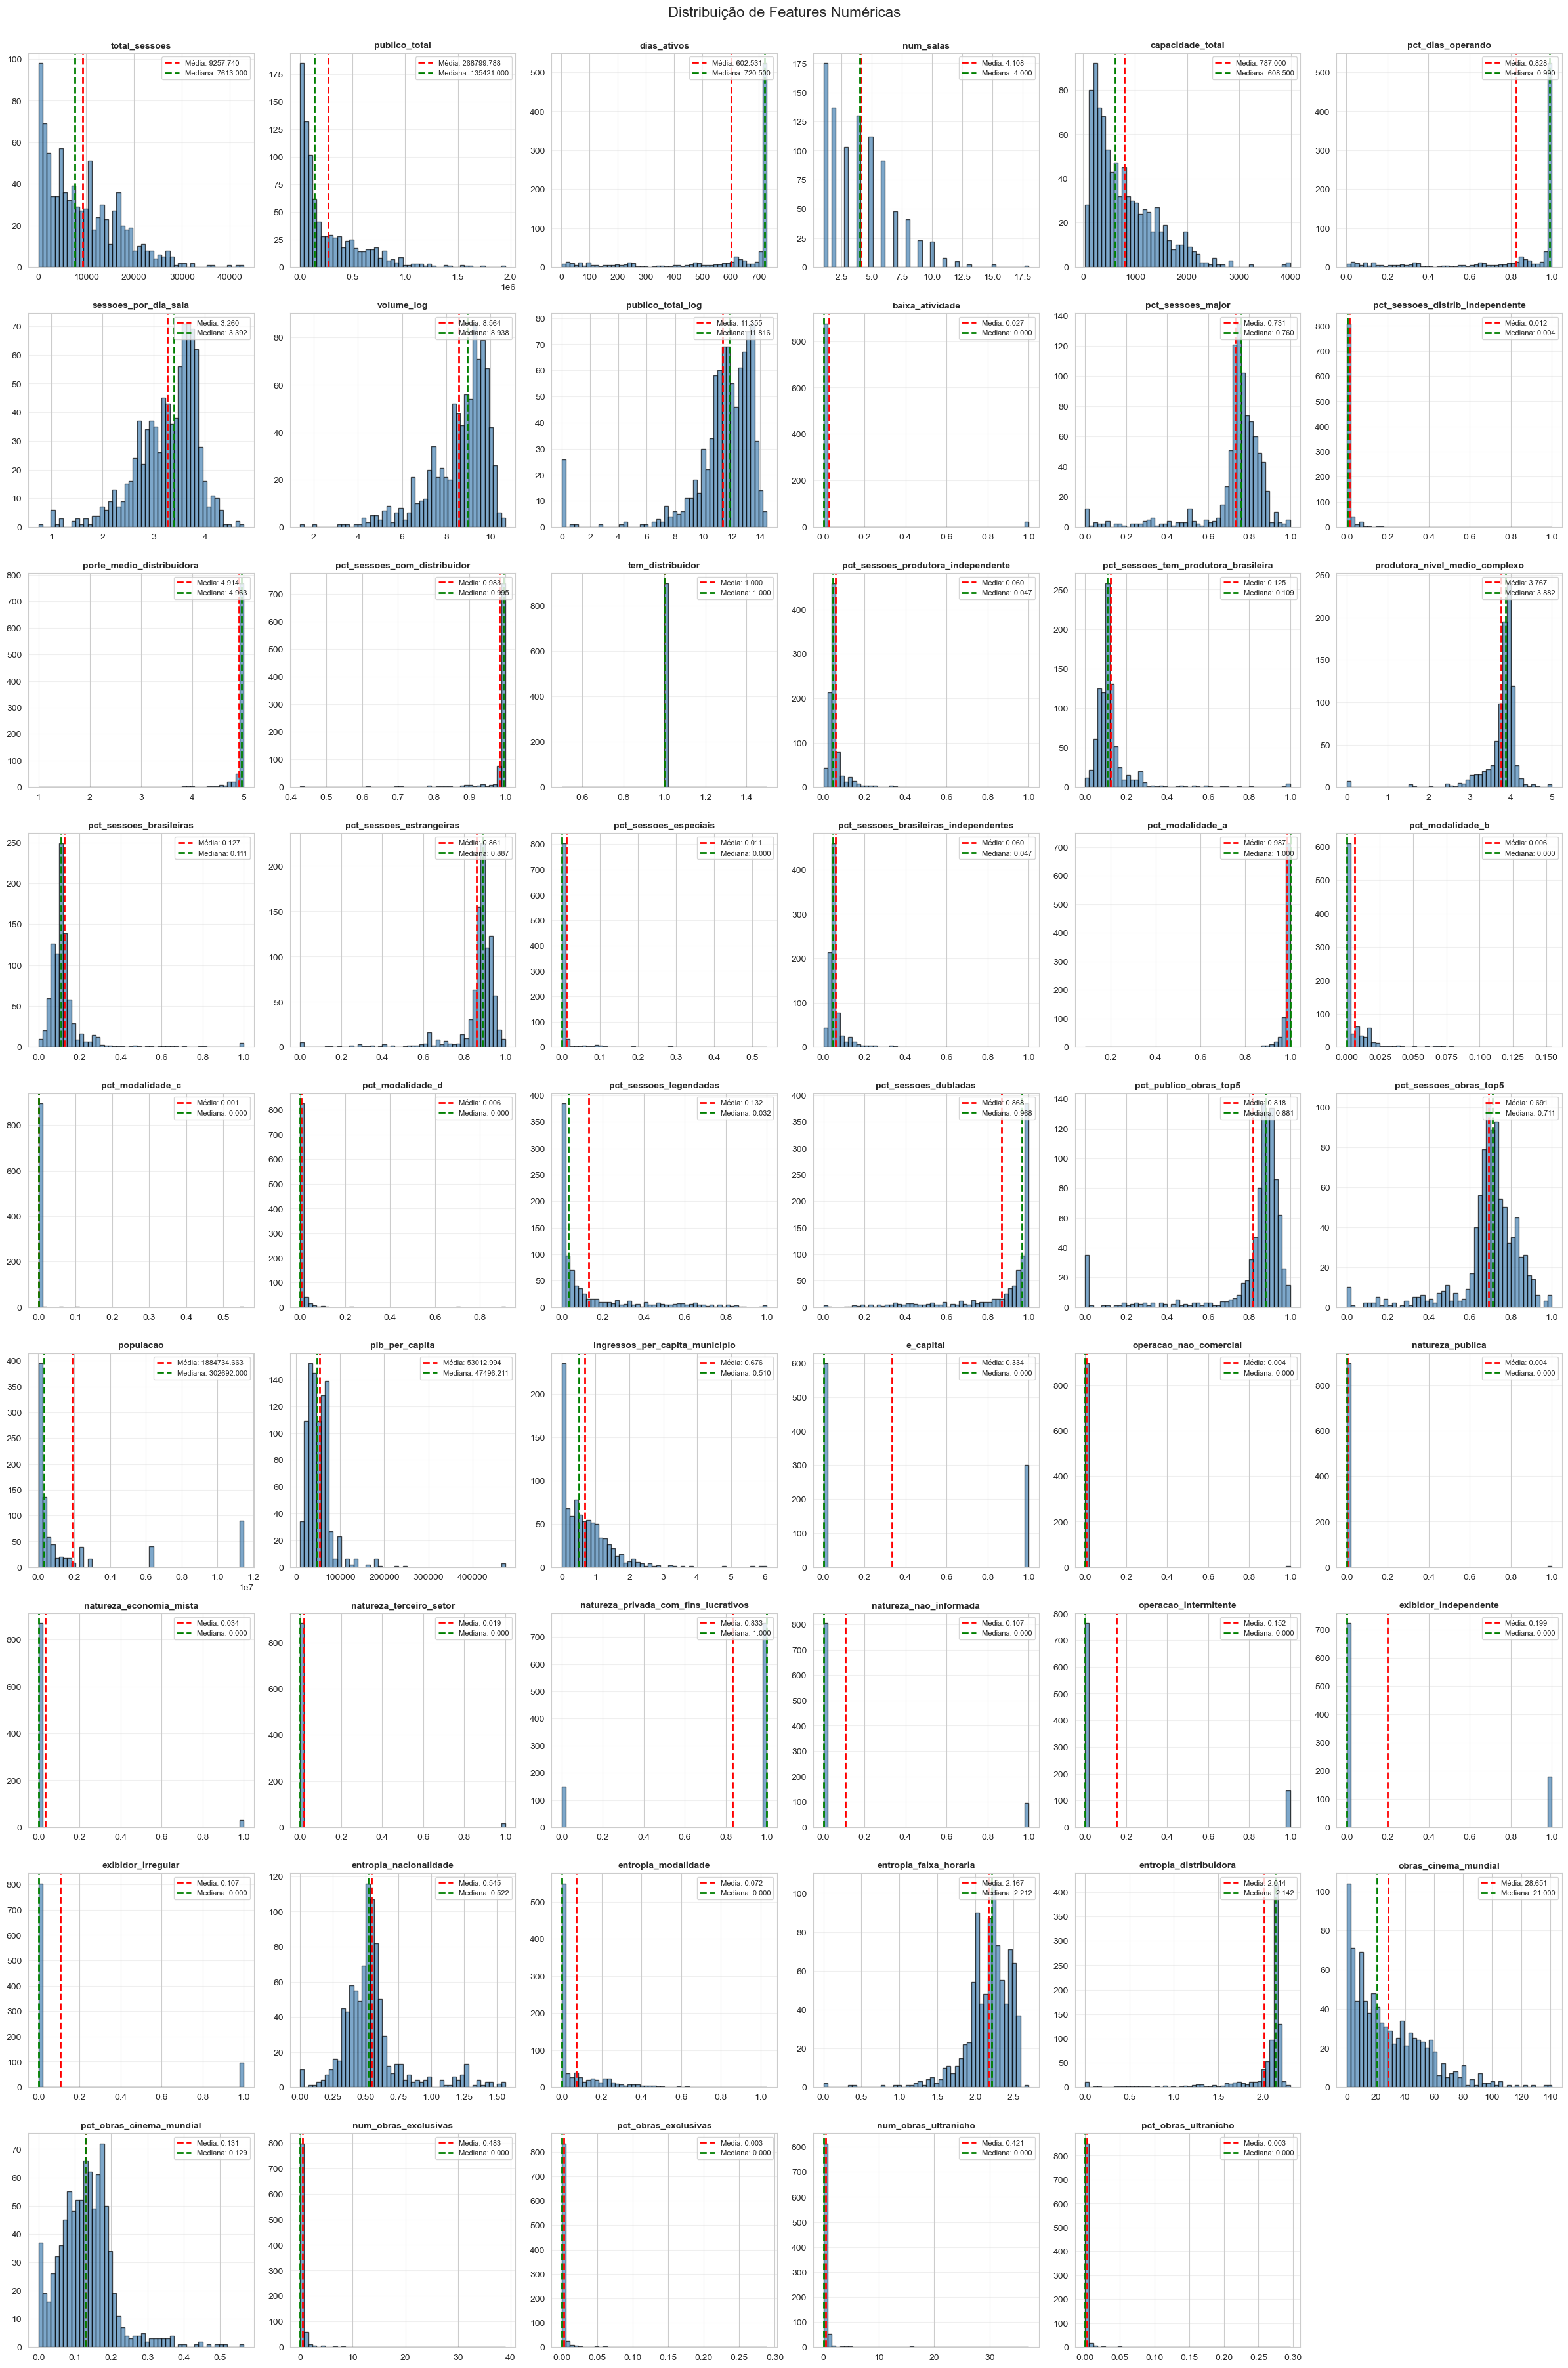

✓ Histogramas salvos em: ../Outputs/distribuicao_features.png


In [12]:
# Calcular grid dimensions
n_features = len(numeric_cols)
n_cols = 6
n_rows = int(np.ceil(n_features / n_cols))

# Criar grid de histogramas
fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, n_rows * 4))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    
    # Histograma
    df[col].hist(bins=50, ax=ax, edgecolor='black', alpha=0.7, color='steelblue')
    
    # Título e estatísticas
    mean_val = df[col].mean()
    median_val = df[col].median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Média: {mean_val:.3f}')
    ax.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Mediana: {median_val:.3f}')
    
    ax.set_title(col, fontsize=10, weight='bold')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(axis='y', alpha=0.3)

# Remover axes extras
for idx in range(n_features, len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Distribuição de Features Numéricas', fontsize=16, y=1.001)
plt.tight_layout()
plt.savefig('../Outputs/distribuicao_features.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Histogramas salvos em: ../Outputs/distribuicao_features.png")

### 2.5 Identificação de Outliers

**Importante:** Não iremos remover outliers - apenas documentá-los

In [13]:
# Função para detectar outliers via IQR
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = (series < lower_bound) | (series > upper_bound)
    return outliers.sum(), lower_bound, upper_bound

# Analisar outliers em features chave
outlier_summary = []
for col in numeric_cols:
    n_outliers, lower, upper = detect_outliers_iqr(df[col])
    if n_outliers > 0:
        outlier_summary.append({
            'Feature': col,
            'N_Outliers': n_outliers,
            'Pct': (n_outliers / len(df) * 100).round(2),
            'Lower_Bound': lower,
            'Upper_Bound': upper
        })

if len(outlier_summary) > 0:
    print("=" * 80)
    print("OUTLIERS DETECTADOS (IQR Method)")
    print("=" * 80)
    outlier_df = pd.DataFrame(outlier_summary).sort_values('N_Outliers', ascending=False)
    print(outlier_df.to_string(index=False))
    print(f"\n⚠️ Total: {len(outlier_summary)} features com outliers detectados")
    print("⚠️ Ação: MANTER todos os complexos (decisão de negócio)")
else:
    print("✓ Nenhum outlier detectado via IQR")

OUTLIERS DETECTADOS (IQR Method)
                              Feature  N_Outliers   Pct   Lower_Bound  Upper_Bound
                     pct_modalidade_d         209 23.22 -3.126833e-04 5.211388e-04
                exibidor_independente         179 19.89  0.000000e+00 0.000000e+00
 natureza_privada_com_fins_lucrativos         150 16.67  1.000000e+00 1.000000e+00
                    pct_dias_operando         139 15.44  5.267857e-01 1.279533e+00
                          dias_ativos         139 15.44  3.835000e+02 9.315000e+02
                operacao_intermitente         137 15.22  0.000000e+00 0.000000e+00
               entropia_distribuidora         135 15.00  1.932010e+00 2.302055e+00
                            populacao         131 14.56 -1.878310e+06 3.426772e+06
                pct_sessoes_especiais         128 14.22 -3.831203e-03 6.385339e-03
pct_sessoes_brasileiras_independentes         127 14.11  1.143300e-02 8.361523e-02
   pct_sessoes_produtora_independente         127 14.1

In [14]:
# Casos extremos específicos (conforme regras de negócio)
print("\n" + "=" * 80)
print("CASOS EXTREMOS ESPECÍFICOS")
print("=" * 80)

# 1. Complexos com público = 0
if 'publico_total' in df.columns:
    zero_publico = df[df['publico_total'] == 0]
    print(f"\n1. Complexos com público_total = 0: {len(zero_publico)}")
    if len(zero_publico) > 0:
        print("   → Cinemas públicos/culturais com entrada gratuita que não registram público na sessão")
        print("   → MANTIDOS no dataset")

# 2. Complexos com 100% cinema brasileiro
if 'pct_sessoes_brasileiras' in df.columns:
    cem_pct_br = df[df['pct_sessoes_brasileiras'] >= 0.99]
    print(f"\n2. Complexos com ≥99% sessões brasileiras: {len(cem_pct_br)}")
    if len(cem_pct_br) > 0:
        print("   → Circuitos municipais especializados")
        print("   → MANTIDOS no dataset")
        if 'UF' in df.columns and 'municipio' in df.columns:
            print("\n   Exemplos:")
            exemplos = cem_pct_br[['municipio', 'UF', 'pct_sessoes_brasileiras']].head(5)
            print(exemplos.to_string(index=False))

# 3. Baixíssima atividade
if 'total_sessoes' in df.columns:
    baixa_ativ = df[df['total_sessoes'] < 10]
    print(f"\n3. Complexos com < 10 sessões no período: {len(baixa_ativ)}")
    if len(baixa_ativ) > 0:
        print("   → Casos extremos de baixa atividade")
        print("   → MANTIDOS no dataset")

print("\n✓ Todos os casos extremos serão mantidos para análise de clustering")


CASOS EXTREMOS ESPECÍFICOS

1. Complexos com público_total = 0: 26
   → Cinemas públicos/culturais com entrada gratuita que não registram público na sessão
   → MANTIDOS no dataset

2. Complexos com ≥99% sessões brasileiras: 4
   → Circuitos municipais especializados
   → MANTIDOS no dataset

   Exemplos:
             municipio UF  pct_sessoes_brasileiras
                 ARCOS MG                      1.0
SANTO ANTÔNIO DO MONTE MG                      1.0
               FORMIGA MG                      1.0
                 PAINS MG                      1.0

3. Complexos com < 10 sessões no período: 2
   → Casos extremos de baixa atividade
   → MANTIDOS no dataset

✓ Todos os casos extremos serão mantidos para análise de clustering


In [15]:
print("\n" + "="*80)
print("INTERPRETAÇÃO DOS OUTLIERS")
print("="*80)

print("\n✅ VALIDAÇÃO:")
print("   • 51 features com outliers detectados (método IQR)")
print("   • Casos extremos investigados acima:")
print("     - 26 complexos com público=0 (cinemas públicos gratuitos que não registram público na sesão)")
print("     - 4 complexos 99%+ brasileiros (circuitos municipais MG)")
print("     - 2 complexos baixíssima atividade (<10 sessões)")
print("   • TODOS são casos válidos de negócio")

print("\n⚠️ LIMITAÇÕES DO MÉTODO IQR:")
print("   • Features binárias: IQR detecta 'categoria minoritária' como outlier")
print("   • Features com spike em zero: Qualquer valor > 0 é considerado outlier")
print("   • Bounds negativos: Artefato matemático para features assimétricas")

print("\n🎯 DECISÃO FINAL:")
print("   • MANTER todos os 900 complexos (sem remoção)")
print("   • Outliers representam segmentos importantes do mercado cinematográfico")
print("   • StandardScaler é robusto a outliers moderados")
print("   • Casos extremos serão identificados com flag 'caso_extremo_atividade'")

print("="*80)


INTERPRETAÇÃO DOS OUTLIERS

✅ VALIDAÇÃO:
   • 51 features com outliers detectados (método IQR)
   • Casos extremos investigados acima:
     - 26 complexos com público=0 (cinemas públicos gratuitos que não registram público na sesão)
     - 4 complexos 99%+ brasileiros (circuitos municipais MG)
     - 2 complexos baixíssima atividade (<10 sessões)
   • TODOS são casos válidos de negócio

⚠️ LIMITAÇÕES DO MÉTODO IQR:
   • Features binárias: IQR detecta 'categoria minoritária' como outlier
   • Features com spike em zero: Qualquer valor > 0 é considerado outlier
   • Bounds negativos: Artefato matemático para features assimétricas

🎯 DECISÃO FINAL:
   • MANTER todos os 900 complexos (sem remoção)
   • Outliers representam segmentos importantes do mercado cinematográfico
   • StandardScaler é robusto a outliers moderados
   • Casos extremos serão identificados com flag 'caso_extremo_atividade'


### 2.6 Cálculo de VIF (Variance Inflation Factor)

**Objetivo:** Identificar multicolinearidade (VIF > 10 indica problema)

In [16]:
# Função para calcular VIF com tratamento de erros
def calcular_vif(df_input, features):
    # Remover features com variância zero ou muito baixa
    valid_features = []
    for f in features:
        var = df_input[f].var()
        if var > 1e-10 and not np.isnan(var) and not np.isinf(var):
            # Verificar se tem inf ou nan na coluna
            if not df_input[f].isnull().any() and not np.isinf(df_input[f]).any():
                valid_features.append(f)
            else:
                print(f"   ⚠️ Pulando {f}: contém NaN ou Inf")
        else:
            print(f"   ⚠️ Pulando {f}: variância muito baixa ({var:.2e})")
    
    if len(valid_features) == 0:
        print("   ⚠️ Nenhuma feature válida para VIF")
        return pd.DataFrame(columns=['Feature', 'VIF'])
    
    print(f"   → Calculando VIF para {len(valid_features)} features válidas...")
    
    # Calcular VIF
    vif_data = pd.DataFrame()
    vif_data["Feature"] = valid_features
    
    try:
        vif_values = []
        for i in range(len(valid_features)):
            try:
                vif = variance_inflation_factor(df_input[valid_features].values, i)
                vif_values.append(vif)
            except Exception as e:
                print(f"   ⚠️ Erro ao calcular VIF para {valid_features[i]}: {e}")
                vif_values.append(np.nan)
        
        vif_data["VIF"] = vif_values
    except Exception as e:
        print(f"   ⚠️ Erro geral no cálculo de VIF: {e}")
        vif_data["VIF"] = [np.nan] * len(valid_features)
    
    return vif_data.sort_values('VIF', ascending=False)

# Calcular VIF para features numéricas
print("Calculando VIF... (pode levar alguns minutos)")
print()
vif_results = calcular_vif(df, numeric_cols)

print("\n" + "=" * 80)
print("VIF - VARIANCE INFLATION FACTOR")
print("=" * 80)
print(vif_results.head(20).to_string(index=False))

# Identificar features problemáticas
high_vif = vif_results[vif_results['VIF'] > 10]
if len(high_vif) > 0:
    print(f"\n⚠️ Features com VIF > 10: {len(high_vif)}")
    print(high_vif.to_string(index=False))
else:
    print("\n✓ Nenhuma feature com VIF > 10")

Calculando VIF... (pode levar alguns minutos)

   ⚠️ Pulando tem_distribuidor: variância muito baixa (0.00e+00)
   → Calculando VIF para 52 features válidas...

VIF - VARIANCE INFLATION FACTOR
                              Feature        VIF
                          dias_ativos        inf
                pct_sessoes_especiais        inf
             pct_sessoes_estrangeiras        inf
                    pct_dias_operando        inf
              pct_sessoes_brasileiras        inf
   pct_sessoes_produtora_independente        inf
               pct_sessoes_legendadas        inf
                     pct_modalidade_d        inf
                     pct_modalidade_c        inf
                     pct_modalidade_b        inf
                     pct_modalidade_a        inf
                   exibidor_irregular        inf
               natureza_nao_informada        inf
                 pct_sessoes_dubladas        inf
pct_sessoes_brasileiras_independentes        inf
 pct_sessoes_tem_produt

In [17]:
print("\n" + "="*80)
print("ANÁLISE DO VIF E DECISÕES DE REMOÇÃO")
print("="*80)

print("\n🚨 VIF INFINITO (15 features) - Colinearidade perfeita:")
print("\n   ✅ Já na lista de remoção:")
print("      • dias_ativos (manter pct_dias_operando)")
print("      • pct_sessoes_estrangeiras (manter brasileiras)")
print("      • pct_sessoes_dubladas (manter legendadas)")
print("      • exibidor_irregular (manter natureza_nao_informada)")
print("      • pct_sessoes_brasileiras_independentes (redundante)")
print("      • pct_modalidade_a (baseline)")

print("\n   ⚠️ Features obrigatórias com VIF INF:")
print("      • pct_sessoes_especiais: MANTER (Art. 6º)")
print("      • pct_modalidade_b/c/d: MANTER (Art. 6º)")
print("        → VIF INF é aceitável para features regulatórias obrigatórias")

print("\n📊 VIF ALTO (>40) - Será reduzido após remoções:")
print("   • volume_log (VIF=47): OK - removendo total_sessoes/publico_total")
print("   • pct_sessoes_major (VIF=42): OK - conceito diferente de top5")
print("   • num_salas (VIF=36): OK - removendo capacidade_total")

print("\n✅ EXPECTATIVA:")
print("   Após remoção das 12 features colineares, VIF médio deve cair")
print("   significativamente. Algumas features obrigatórias manterão VIF alto")
print("   por questões regulatórias (Art. 6º ANCINE).")

print("="*80)


ANÁLISE DO VIF E DECISÕES DE REMOÇÃO

🚨 VIF INFINITO (15 features) - Colinearidade perfeita:

   ✅ Já na lista de remoção:
      • dias_ativos (manter pct_dias_operando)
      • pct_sessoes_estrangeiras (manter brasileiras)
      • pct_sessoes_dubladas (manter legendadas)
      • exibidor_irregular (manter natureza_nao_informada)
      • pct_sessoes_brasileiras_independentes (redundante)
      • pct_modalidade_a (baseline)

   ⚠️ Features obrigatórias com VIF INF:
      • pct_sessoes_especiais: MANTER (Art. 6º)
      • pct_modalidade_b/c/d: MANTER (Art. 6º)
        → VIF INF é aceitável para features regulatórias obrigatórias

📊 VIF ALTO (>40) - Será reduzido após remoções:
   • volume_log (VIF=47): OK - removendo total_sessoes/publico_total
   • pct_sessoes_major (VIF=42): OK - conceito diferente de top5
   • num_salas (VIF=36): OK - removendo capacidade_total

✅ EXPECTATIVA:
   Após remoção das 12 features colineares, VIF médio deve cair
   significativamente. Algumas features obrig

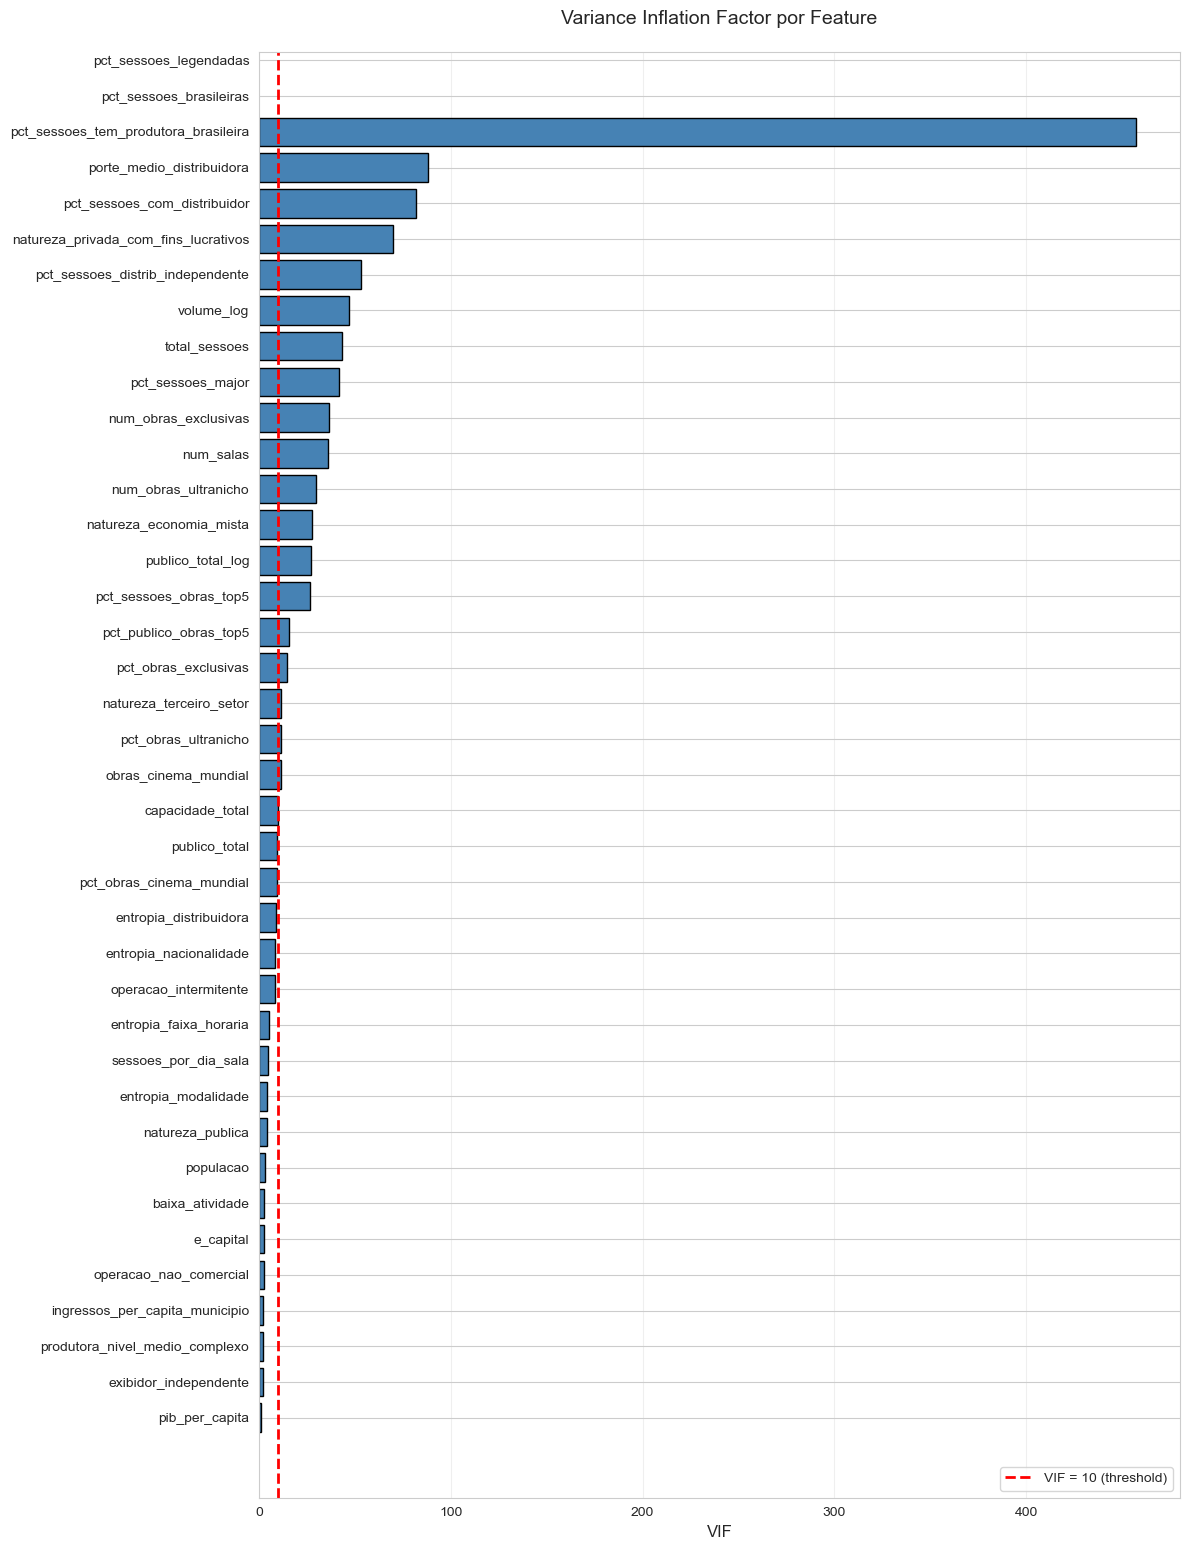

✓ Gráfico VIF salvo em: ../Outputs/vif_features.png


In [18]:
# Visualizar VIF
plt.figure(figsize=(12, max(8, len(vif_results) * 0.3)))
vif_plot = vif_results.sort_values('VIF', ascending=True)
plt.barh(vif_plot['Feature'], vif_plot['VIF'], color='steelblue', edgecolor='black')
plt.axvline(x=10, color='red', linestyle='--', linewidth=2, label='VIF = 10 (threshold)')
plt.xlabel('VIF', fontsize=12)
plt.title('Variance Inflation Factor por Feature', fontsize=14, pad=20)
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../Outputs/vif_features.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Gráfico VIF salvo em: ../Outputs/vif_features.png")

---
## 3. Aplicação de Regras de Negócio

### 3.1 Consolidação de Natureza Jurídica

**Regra:** Criar feature agregada `natureza_nao_privada` e remover colunas individuais

In [19]:
# Verificar se colunas de natureza jurídica existem
natureza_cols = ['natureza_publica', 'natureza_economia_mista', 'natureza_terceiro_setor',
                'natureza_privada_com_fins_lucrativos', 'natureza_nao_informada']

missing_cols = [col for col in natureza_cols if col not in df.columns]
if missing_cols:
    print(f"⚠️ ATENÇÃO: Colunas não encontradas: {missing_cols}")
    print("   Verifique se o dataset contém features de natureza jurídica")
else:
    # Criar feature agregada
    df['natureza_nao_privada'] = (
        (df['natureza_publica'] == 1) | 
        (df['natureza_economia_mista'] == 1) | 
        (df['natureza_terceiro_setor'] == 1)
    ).astype(int)
    
    print("=" * 80)
    print("CONSOLIDAÇÃO DE NATUREZA JURÍDICA")
    print("=" * 80)
    print(f"\n✓ Feature criada: natureza_nao_privada")
    print(f"  - Complexos não-privados: {df['natureza_nao_privada'].sum()} ({df['natureza_nao_privada'].mean()*100:.1f}%)")
    
    # Distribuição detalhada
    print("\nDistribuição original:")
    for col in natureza_cols:
        n = df[col].sum()
        pct = (n / len(df) * 100)
        print(f"  - {col}: {n} ({pct:.1f}%)")
    
    # Remover colunas individuais (exceto natureza_nao_informada)
    cols_to_remove = ['natureza_publica', 'natureza_economia_mista', 
                     'natureza_terceiro_setor', 'natureza_privada_com_fins_lucrativos']
    df = df.drop(columns=cols_to_remove)
    
    print(f"\n✓ Removidas {len(cols_to_remove)} colunas individuais")
    print(f"✓ Mantidas: natureza_nao_privada, natureza_nao_informada")
    print(f"\n✓ Shape atual: {df.shape}")

CONSOLIDAÇÃO DE NATUREZA JURÍDICA

✓ Feature criada: natureza_nao_privada
  - Complexos não-privados: 52 (5.8%)

Distribuição original:
  - natureza_publica: 4 (0.4%)
  - natureza_economia_mista: 31 (3.4%)
  - natureza_terceiro_setor: 17 (1.9%)
  - natureza_privada_com_fins_lucrativos: 750 (83.3%)
  - natureza_nao_informada: 96 (10.7%)

✓ Removidas 4 colunas individuais
✓ Mantidas: natureza_nao_privada, natureza_nao_informada

✓ Shape atual: (900, 55)


In [20]:
print("\n💡 JUSTIFICATIVA DA CONSOLIDAÇÃO:")
print("   • Categorias individuais muito pequenas (4, 17, 31 complexos)")
print("   • Agrupamento teoricamente coerente: missão não-lucrativa")
print("   • Reduz dimensionalidade (5→2) sem perda de informação relevante")
print("   • Melhora poder estatístico para clustering")
print("\n✓ Baseline implícita: natureza_privada_com_fins_lucrativos (750)")


💡 JUSTIFICATIVA DA CONSOLIDAÇÃO:
   • Categorias individuais muito pequenas (4, 17, 31 complexos)
   • Agrupamento teoricamente coerente: missão não-lucrativa
   • Reduz dimensionalidade (5→2) sem perda de informação relevante
   • Melhora poder estatístico para clustering

✓ Baseline implícita: natureza_privada_com_fins_lucrativos (750)


### 3.2 Remoção de Features Colineares

**Regra:** Remover features complementares (que somam 100%)

In [21]:
print("=" * 80)
print("REMOÇÃO DE FEATURES COLINEARES")
print("=" * 80)

# Lista consolidada de features a remover
features_colineares = [
    # Pares complementares (somam 100%)
    'pct_sessoes_estrangeiras',      # complementar de brasileiras
    'pct_sessoes_dubladas',          # complementar de legendadas
    
    # Pares idênticos/redundantes (r ≈ 1.0)
    'exibidor_irregular',            # idêntico a natureza_nao_informada
    'pct_sessoes_brasileiras_independentes',  # idêntico a produtora_independente
    'dias_ativos',                   # idêntico a pct_dias_operando
    'pct_sessoes_tem_produtora_brasileira',  # r=0.997 com pct_sessoes_brasileiras
    
    # Métricas de volume redundantes
    'total_sessoes',                 # redundante com volume_log
    'publico_total',                 # redundante com volume_log
    'publico_total_log',             # redundante com volume_log
    'capacidade_total',              # alta correlação com num_salas
    
    # Modalidades e outras
    'pct_modalidade_a',              # baseline (maior categoria)
    'num_obras_exclusivas',          # redundante com pct_obras_exclusivas
    
    # Variância zero
    'tem_distribuidor'               # todos valores iguais
]

# Verificar quais existem no dataset
existing = [col for col in features_colineares if col in df.columns]
missing = [col for col in features_colineares if col not in df.columns]

print(f"\nRemovendo {len(existing)} features colineares:\n")
for col in existing:
    print(f"  ✗ {col}")

if missing:
    print(f"\n⚠️ Features não encontradas (já removidas?):")
    for col in missing:
        print(f"  - {col}")

# Remover
df = df.drop(columns=existing)

print(f"\n✓ {len(existing)} features removidas com sucesso")
print(f"\n✓ Shape atual: {df.shape}")

# Resumo do que foi mantido
print(f"\n📊 RESUMO:")
print(f"  - Features removidas: {len(existing)}")
print(f"  - Features restantes: {df.shape[1]}")
print(f"  - Complexos: {df.shape[0]} (inalterado)")

print("\n" + "=" * 80)

REMOÇÃO DE FEATURES COLINEARES

Removendo 13 features colineares:

  ✗ pct_sessoes_estrangeiras
  ✗ pct_sessoes_dubladas
  ✗ exibidor_irregular
  ✗ pct_sessoes_brasileiras_independentes
  ✗ dias_ativos
  ✗ pct_sessoes_tem_produtora_brasileira
  ✗ total_sessoes
  ✗ publico_total
  ✗ publico_total_log
  ✗ capacidade_total
  ✗ pct_modalidade_a
  ✗ num_obras_exclusivas
  ✗ tem_distribuidor

✓ 13 features removidas com sucesso

✓ Shape atual: (900, 42)

📊 RESUMO:
  - Features removidas: 13
  - Features restantes: 42
  - Complexos: 900 (inalterado)



### 3.3 Marcação de Casos Extremos

**Importante:** Marcar mas NÃO remover complexos

In [22]:
# Criar flag de caso extremo de atividade
if 'volume_log' in df.columns:
    # Definir threshold baseado em percentil baixo
    threshold_log = df['volume_log'].quantile(0.05)
    df['caso_extremo_atividade'] = (df['volume_log'] < threshold_log).astype(int)
else:
    print("⚠️ Não foi possível criar flag caso_extremo_atividade")
    df['caso_extremo_atividade'] = 0

print("=" * 80)
print("MARCAÇÃO DE CASOS EXTREMOS")
print("=" * 80)

n_extremos = df['caso_extremo_atividade'].sum()
print(f"\n✓ Flag criada: caso_extremo_atividade")
print(f"  - Complexos marcados: {n_extremos} ({n_extremos/len(df)*100:.1f}%)")
print(f"  - Ação: MANTER no dataset (não excluir)")
print(f"\n✓ Todos os {len(df)} complexos mantidos no dataset")

MARCAÇÃO DE CASOS EXTREMOS

✓ Flag criada: caso_extremo_atividade
  - Complexos marcados: 45 (5.0%)
  - Ação: MANTER no dataset (não excluir)

✓ Todos os 900 complexos mantidos no dataset


### 3.4 Validação de Features Obrigatórias

**Verificar se todas as features obrigatórias estão presentes**

In [23]:
# Lista de features obrigatórias
features_obrigatorias = [
    'pct_sessoes_especiais',
    'pct_sessoes_distrib_independente',
    'pct_modalidade_b',
    'pct_modalidade_c',
    'pct_modalidade_d',
    'baixa_atividade',
    'operacao_nao_comercial',
]

print("=" * 80)
print("VALIDAÇÃO DE FEATURES OBRIGATÓRIAS")
print("=" * 80)

# Verificar presença
presentes = [col for col in features_obrigatorias if col in df.columns]
ausentes = [col for col in features_obrigatorias if col not in df.columns]

if len(presentes) == len(features_obrigatorias):
    print(f"\n✓ Todas as {len(features_obrigatorias)} features obrigatórias estão presentes")
    
    # Mostrar distribuição
    print("\nDistribuição:")
    for col in features_obrigatorias:
        if df[col].dtype in ['int64', 'int32']:
            # Feature binária
            n_pos = df[col].sum()
            pct = (n_pos / len(df) * 100)
            print(f"  - {col}: {n_pos} positivos ({pct:.1f}%)")
        else:
            # Feature contínua
            mean_val = df[col].mean()
            median_val = df[col].median()
            print(f"  - {col}: média={mean_val:.4f}, mediana={median_val:.4f}")
else:
    print(f"\n⚠️ ATENÇÃO: Features obrigatórias ausentes:")
    for col in ausentes:
        print(f"  ✗ {col}")
    print("\n⚠️ AÇÃO NECESSÁRIA: Verificar dataset de entrada")

VALIDAÇÃO DE FEATURES OBRIGATÓRIAS

✓ Todas as 7 features obrigatórias estão presentes

Distribuição:
  - pct_sessoes_especiais: média=0.0115, mediana=0.0003
  - pct_sessoes_distrib_independente: média=0.0125, mediana=0.0038
  - pct_modalidade_b: média=0.0060, mediana=0.0000
  - pct_modalidade_c: média=0.0009, mediana=0.0000
  - pct_modalidade_d: média=0.0063, mediana=0.0000
  - baixa_atividade: 24 positivos (2.7%)
  - operacao_nao_comercial: 4 positivos (0.4%)


In [24]:
print("\n💡 INTERPRETAÇÃO:")
print("   • Features percentuais altamente assimétricas (mediana ≈ 0)")
print("     → Maioria dos complexos não exibe modalidades b/c/d ou sessões especiais")
print("     → Mercado concentrado em modalidade A e majors")
print("   • Features binárias com poucos positivos (2.7%, 0.4%)")
print("     → Identificam segmentos minoritários mas regulatoriamente importantes")
print("\n⚠️ IMPLICAÇÃO PARA CLUSTERING:")
print("   • Baixa variância pode limitar poder discriminatório")
print("   • Mas remoção não é opção (obrigatórias Art. 6º ANCINE)")
print("   • Análise pós-clustering dirá se diferenciam clusters")


💡 INTERPRETAÇÃO:
   • Features percentuais altamente assimétricas (mediana ≈ 0)
     → Maioria dos complexos não exibe modalidades b/c/d ou sessões especiais
     → Mercado concentrado em modalidade A e majors
   • Features binárias com poucos positivos (2.7%, 0.4%)
     → Identificam segmentos minoritários mas regulatoriamente importantes

⚠️ IMPLICAÇÃO PARA CLUSTERING:
   • Baixa variância pode limitar poder discriminatório
   • Mas remoção não é opção (obrigatórias Art. 6º ANCINE)
   • Análise pós-clustering dirá se diferenciam clusters


---
## 4. Criação de Features Compostas

### 4.1 Feature: pct_obras_nao_anglo

**Objetivo:** Medir abertura para cinema além de EUA/UK/CAN

In [25]:
# Verificar componentes necessários
componentes_nao_anglo = ['pct_sessoes_brasileiras', 'pct_obras_cinema_mundial']
missing_comps = [col for col in componentes_nao_anglo if col not in df.columns]

if not missing_comps:
    # Criar feature composta
    df['pct_obras_nao_anglo'] = (
        df['pct_sessoes_brasileiras'] + 
        df['pct_obras_cinema_mundial']
    )
    
    print("=" * 80)
    print("FEATURE COMPOSTA: pct_obras_nao_anglo")
    print("=" * 80)
    print("\nFórmula: pct_sessoes_brasileiras + pct_obras_cinema_mundial")
    print("Interpretação: Percentual de obras não-anglófonas (BR + Cinema Mundial)")
    
    # Estatísticas
    print(f"\nEstatísticas:")
    print(f"  - Média: {df['pct_obras_nao_anglo'].mean():.4f} ({df['pct_obras_nao_anglo'].mean()*100:.1f}%)")
    print(f"  - Mediana: {df['pct_obras_nao_anglo'].median():.4f}")
    print(f"  - Min: {df['pct_obras_nao_anglo'].min():.4f}")
    print(f"  - Max: {df['pct_obras_nao_anglo'].max():.4f}")
    print(f"  - Std: {df['pct_obras_nao_anglo'].std():.4f}")
    
    # Validação
    assert df['pct_obras_nao_anglo'].isnull().sum() == 0, "⚠️ Nulls detectados!"
    assert (df['pct_obras_nao_anglo'] >= 0).all(), "⚠️ Valores negativos detectados!"
    print("\n✓ Feature criada e validada com sucesso")
else:
    print(f"⚠️ Não foi possível criar pct_obras_nao_anglo - componentes ausentes: {missing_comps}")

FEATURE COMPOSTA: pct_obras_nao_anglo

Fórmula: pct_sessoes_brasileiras + pct_obras_cinema_mundial
Interpretação: Percentual de obras não-anglófonas (BR + Cinema Mundial)

Estatísticas:
  - Média: 0.2587 (25.9%)
  - Mediana: 0.2430
  - Min: 0.0000
  - Max: 1.0000
  - Std: 0.1397

✓ Feature criada e validada com sucesso


### 4.2 Feature: desproporcao_blockbuster

**Captura a desproporção entre concentração de público vs sessões nos top5**

In [26]:
print("=" * 80)
print("FEATURE COMPOSTA: desproporcao_blockbuster")
print("=" * 80)

# Verificar componentes
required = ['pct_publico_obras_top5', 'pct_sessoes_obras_top5']
if all(col in df.columns for col in required):
    
    # Criar feature
    df['desproporcao_blockbuster'] = (
        df['pct_publico_obras_top5'] - df['pct_sessoes_obras_top5']
    )
    
    print("\nFórmula: pct_publico_obras_top5 - pct_sessoes_obras_top5")
    print("Interpretação: Diferença entre concentração de público vs sessões")
    print("  - Valor positivo: Blockbusters atraem desproporcionalmente mais público")
    print("  - Valor ~0: Distribuição proporcional")
    print("  - Valor negativo: Sessões concentradas, mas público disperso (raro)")
    
    # Estatísticas
    stats = df['desproporcao_blockbuster'].describe()
    print("\nEstatísticas:")
    print(f"  - Média: {stats['mean']:.4f}")
    print(f"  - Mediana: {stats['50%']:.4f}")
    print(f"  - Min: {stats['min']:.4f}")
    print(f"  - Max: {stats['max']:.4f}")
    print(f"  - Std: {stats['std']:.4f}")
    
    # Distribuição em quartis
    print("\nDistribuição:")
    print(f"  - P25: {stats['25%']:.4f}")
    print(f"  - P50: {stats['50%']:.4f}")
    print(f"  - P75: {stats['75%']:.4f}")
    
    # Interpretação dos valores
    positivos = (df['desproporcao_blockbuster'] > 0.05).sum()
    neutros = ((df['desproporcao_blockbuster'] >= -0.05) & 
               (df['desproporcao_blockbuster'] <= 0.05)).sum()
    negativos = (df['desproporcao_blockbuster'] < -0.05).sum()
    
    print(f"\n📊 Interpretação dos valores:")
    print(f"  - Desproporção alta (>0.05): {positivos} ({positivos/len(df)*100:.1f}%)")
    print(f"    → Blockbusters dominam público desproporcionalmente")
    print(f"  - Neutro (-0.05 a 0.05): {neutros} ({neutros/len(df)*100:.1f}%)")
    print(f"    → Distribuição proporcional")
    print(f"  - Desproporção negativa (<-0.05): {negativos} ({negativos/len(df)*100:.1f}%)")
    print(f"    → Público mais disperso que sessões (cinemas de nicho)")
    
    print("\n✓ Feature criada e validada com sucesso")
    
else:
    missing = [col for col in required if col not in df.columns]
    print(f"⚠️ Componentes faltando: {missing}")
    print("✗ Feature NÃO criada")

print("=" * 80)

FEATURE COMPOSTA: desproporcao_blockbuster

Fórmula: pct_publico_obras_top5 - pct_sessoes_obras_top5
Interpretação: Diferença entre concentração de público vs sessões
  - Valor positivo: Blockbusters atraem desproporcionalmente mais público
  - Valor ~0: Distribuição proporcional
  - Valor negativo: Sessões concentradas, mas público disperso (raro)

Estatísticas:
  - Média: 0.1273
  - Mediana: 0.1466
  - Min: -0.5363
  - Max: 0.5338
  - Std: 0.1174

Distribuição:
  - P25: 0.1074
  - P50: 0.1466
  - P75: 0.1800

📊 Interpretação dos valores:
  - Desproporção alta (>0.05): 830 (92.2%)
    → Blockbusters dominam público desproporcionalmente
  - Neutro (-0.05 a 0.05): 42 (4.7%)
    → Distribuição proporcional
  - Desproporção negativa (<-0.05): 28 (3.1%)
    → Público mais disperso que sessões (cinemas de nicho)

✓ Feature criada e validada com sucesso


### 4.3 Feature: score_curadoria

**Score de curadoria especializada (apenas percentuais)**

In [27]:
print("=" * 80)
print("FEATURE COMPOSTA: score_curadoria")
print("=" * 80)

# Verificar componentes
required = ['pct_obras_exclusivas', 'pct_obras_cinema_mundial', 'pct_obras_ultranicho']
if all(col in df.columns for col in required):
    
    # Criar feature (escala 0-1)
    df['score_curadoria'] = (
        0.5 * df['pct_obras_exclusivas'] +
        0.3 * df['pct_obras_cinema_mundial'] +
        0.2 * df['pct_obras_ultranicho']
    )
    
    print("\nFórmula:")
    print("  0.5 × pct_obras_exclusivas +")
    print("  0.3 × pct_obras_cinema_mundial +")
    print("  0.2 × pct_obras_ultranicho")
    
    print("\nInterpretação: Score de curadoria especializada (0-1)")
    print("  - Peso maior para obras exclusivas (50%)")
    print("  - Cinema mundial contribui com 30%")
    print("  - Obras ultranicho com 20%")
    print("  - Maior valor = cinema com curadoria de nicho")
    
    # Estatísticas
    stats = df['score_curadoria'].describe()
    print("\nEstatísticas:")
    print(f"  - Média: {stats['mean']:.4f}")
    print(f"  - Mediana: {stats['50%']:.4f}")
    print(f"  - Min: {stats['min']:.4f}")
    print(f"  - Max: {stats['max']:.4f}")
    print(f"  - Std: {stats['std']:.4f}")
    
    # Distribuição em quartis
    print("\nDistribuição em quartis:")
    print(f"  - P25: {stats['25%']:.4f}")
    print(f"  - P50: {stats['50%']:.4f}")
    print(f"  - P75: {stats['75%']:.4f}")
    print(f"  - P95: {df['score_curadoria'].quantile(0.95):.4f}")
    
    # Categorização
    comercial_puro = (df['score_curadoria'] < 0.01).sum()
    baixa_curadoria = ((df['score_curadoria'] >= 0.01) & (df['score_curadoria'] < 0.05)).sum()
    media_curadoria = ((df['score_curadoria'] >= 0.05) & (df['score_curadoria'] < 0.15)).sum()
    alta_curadoria = (df['score_curadoria'] >= 0.15).sum()
    
    print(f"\n📊 Perfis de curadoria:")
    print(f"  - Comercial puro (<0.01): {comercial_puro} ({comercial_puro/len(df)*100:.1f}%)")
    print(f"  - Baixa curadoria (0.01-0.05): {baixa_curadoria} ({baixa_curadoria/len(df)*100:.1f}%)")
    print(f"  - Média curadoria (0.05-0.15): {media_curadoria} ({media_curadoria/len(df)*100:.1f}%)")
    print(f"  - Alta curadoria (≥0.15): {alta_curadoria} ({alta_curadoria/len(df)*100:.1f}%)")
    
    print("\n✓ Feature criada e validada com sucesso")
    
else:
    missing = [col for col in required if col not in df.columns]
    print(f"⚠️ Componentes faltando: {missing}")
    print("✗ Feature NÃO criada")

print("=" * 80)

FEATURE COMPOSTA: score_curadoria

Fórmula:
  0.5 × pct_obras_exclusivas +
  0.3 × pct_obras_cinema_mundial +
  0.2 × pct_obras_ultranicho

Interpretação: Score de curadoria especializada (0-1)
  - Peso maior para obras exclusivas (50%)
  - Cinema mundial contribui com 30%
  - Obras ultranicho com 20%
  - Maior valor = cinema com curadoria de nicho

Estatísticas:
  - Média: 0.0415
  - Mediana: 0.0393
  - Min: 0.0000
  - Max: 0.2993
  - Std: 0.0286

Distribuição em quartis:
  - P25: 0.0253
  - P50: 0.0393
  - P75: 0.0518
  - P95: 0.0882

📊 Perfis de curadoria:
  - Comercial puro (<0.01): 68 (7.6%)
  - Baixa curadoria (0.01-0.05): 570 (63.3%)
  - Média curadoria (0.05-0.15): 251 (27.9%)
  - Alta curadoria (≥0.15): 11 (1.2%)

✓ Feature criada e validada com sucesso


### 4.4 Feature: intensidade_exibicao

**Captura intensidade de uso da infraestrutura**

In [28]:
print("=" * 80)
print("FEATURE COMPOSTA: intensidade_exibicao")
print("=" * 80)

# Verificar componentes
required = ['sessoes_por_dia_sala', 'pct_dias_operando']
if all(col in df.columns for col in required):
    
    # Criar feature
    df['intensidade_exibicao'] = (
        df['sessoes_por_dia_sala'] * df['pct_dias_operando']
    )
    
    print("\nFórmula: sessoes_por_dia_sala × pct_dias_operando")
    print("Interpretação: Intensidade de uso da infraestrutura")
    print("  - Alto valor: Muitas sessões/dia E opera frequentemente")
    print("  - Baixo valor: Poucas sessões/dia OU operação intermitente")
    print("  - Identifica eficiência operacional do complexo")
    
    # Estatísticas
    stats = df['intensidade_exibicao'].describe()
    print("\nEstatísticas:")
    print(f"  - Média: {stats['mean']:.4f}")
    print(f"  - Mediana: {stats['50%']:.4f}")
    print(f"  - Min: {stats['min']:.4f}")
    print(f"  - Max: {stats['max']:.4f}")
    print(f"  - Std: {stats['std']:.4f}")
    
    # Distribuição em quartis
    print("\nDistribuição:")
    print(f"  - P25: {stats['25%']:.4f}")
    print(f"  - P50: {stats['50%']:.4f}")
    print(f"  - P75: {stats['75%']:.4f}")
    
    # Categorização
    quartis = df['intensidade_exibicao'].quantile([0.25, 0.5, 0.75])
    baixa = (df['intensidade_exibicao'] < quartis[0.25]).sum()
    media = ((df['intensidade_exibicao'] >= quartis[0.25]) & 
             (df['intensidade_exibicao'] < quartis[0.75])).sum()
    alta = (df['intensidade_exibicao'] >= quartis[0.75]).sum()
    
    print(f"\n📊 Intensidade operacional:")
    print(f"  - Baixa (<P25): {baixa} complexos ({baixa/len(df)*100:.1f}%)")
    print(f"    → Subutilização ou operação sazonal")
    print(f"  - Média (P25-P75): {media} complexos ({media/len(df)*100:.1f}%)")
    print(f"    → Operação padrão")
    print(f"  - Alta (≥P75): {alta} complexos ({alta/len(df)*100:.1f}%)")
    print(f"    → Uso intensivo da infraestrutura")
    
    print("\n✓ Feature criada e validada com sucesso")
    
else:
    missing = [col for col in required if col not in df.columns]
    print(f"⚠️ Componentes faltando: {missing}")
    print("✗ Feature NÃO criada")

print("=" * 80)

FEATURE COMPOSTA: intensidade_exibicao

Fórmula: sessoes_por_dia_sala × pct_dias_operando
Interpretação: Intensidade de uso da infraestrutura
  - Alto valor: Muitas sessões/dia E opera frequentemente
  - Baixo valor: Poucas sessões/dia OU operação intermitente
  - Identifica eficiência operacional do complexo

Estatísticas:
  - Média: 2.7546
  - Mediana: 3.1102
  - Min: 0.0021
  - Max: 4.6168
  - Std: 1.1182

Distribuição:
  - P25: 2.2364
  - P50: 3.1102
  - P75: 3.6237

📊 Intensidade operacional:
  - Baixa (<P25): 225 complexos (25.0%)
    → Subutilização ou operação sazonal
  - Média (P25-P75): 450 complexos (50.0%)
    → Operação padrão
  - Alta (≥P75): 225 complexos (25.0%)
    → Uso intensivo da infraestrutura

✓ Feature criada e validada com sucesso


### 4.5 Feature: perfil_independente

**Score de independência do circuito comercial mainstream**

In [29]:
print("=" * 80)
print("FEATURE COMPOSTA: perfil_independente")
print("=" * 80)

# Verificar componentes
required = ['pct_sessoes_distrib_independente', 'pct_sessoes_produtora_independente', 
            'exibidor_independente']
if all(col in df.columns for col in required):
    
    # Criar feature (escala 0-1)
    df['perfil_independente'] = (
        0.4 * df['pct_sessoes_distrib_independente'] +
        0.4 * df['pct_sessoes_produtora_independente'] +
        0.2 * df['exibidor_independente']
    )
    
    print("\nFórmula:")
    print("  0.4 × pct_sessoes_distrib_independente +")
    print("  0.3 × pct_sessoes_produtora_independente +")
    print("  0.3 × exibidor_independente")
    
    print("\nInterpretação: Score de independência (0-1)")
    print("  - Agrega 3 dimensões de independência:")
    print("    • Distribuidor independente (peso 40%)")
    print("    • Produtor independente (peso 30%)")
    print("    • Exibidor independente (peso 30%)")
    print("  - Maior valor = cinema fora do mainstream comercial")
    
    # Estatísticas
    stats = df['perfil_independente'].describe()
    print("\nEstatísticas:")
    print(f"  - Média: {stats['mean']:.4f}")
    print(f"  - Mediana: {stats['50%']:.4f}")
    print(f"  - Min: {stats['min']:.4f}")
    print(f"  - Max: {stats['max']:.4f}")
    print(f"  - Std: {stats['std']:.4f}")
    
    # Distribuição em quartis
    print("\nDistribuição:")
    print(f"  - P25: {stats['25%']:.4f}")
    print(f"  - P50: {stats['50%']:.4f}")
    print(f"  - P75: {stats['75%']:.4f}")
    print(f"  - P95: {df['perfil_independente'].quantile(0.95):.4f}")
    
    # Categorização
    mainstream = (df['perfil_independente'] < 0.05).sum()
    baixa_indep = ((df['perfil_independente'] >= 0.05) & (df['perfil_independente'] < 0.15)).sum()
    media_indep = ((df['perfil_independente'] >= 0.15) & (df['perfil_independente'] < 0.30)).sum()
    alta_indep = (df['perfil_independente'] >= 0.30).sum()
    
    print(f"\n📊 Perfis de mercado:")
    print(f"  - Mainstream puro (<0.05): {mainstream} ({mainstream/len(df)*100:.1f}%)")
    print(f"    → Dominado por majors e redes comerciais")
    print(f"  - Baixa independência (0.05-0.15): {baixa_indep} ({baixa_indep/len(df)*100:.1f}%)")
    print(f"  - Média independência (0.15-0.30): {media_indep} ({media_indep/len(df)*100:.1f}%)")
    print(f"  - Alta independência (≥0.30): {alta_indep} ({alta_indep/len(df)*100:.1f}%)")
    print(f"    → Circuito independente consolidado")
    
    print("\n✓ Feature criada e validada com sucesso")
    
else:
    missing = [col for col in required if col not in df.columns]
    print(f"⚠️ Componentes faltando: {missing}")
    print("✗ Feature NÃO criada")

print("=" * 80)

FEATURE COMPOSTA: perfil_independente

Fórmula:
  0.4 × pct_sessoes_distrib_independente +
  0.3 × pct_sessoes_produtora_independente +
  0.3 × exibidor_independente

Interpretação: Score de independência (0-1)
  - Agrega 3 dimensões de independência:
    • Distribuidor independente (peso 40%)
    • Produtor independente (peso 30%)
    • Exibidor independente (peso 30%)
  - Maior valor = cinema fora do mainstream comercial

Estatísticas:
  - Média: 0.0687
  - Mediana: 0.0225
  - Min: 0.0000
  - Max: 0.8000
  - Std: 0.0947

Distribuição:
  - P25: 0.0184
  - P50: 0.0225
  - P75: 0.0525
  - P95: 0.2312

📊 Perfis de mercado:
  - Mainstream puro (<0.05): 669 (74.3%)
    → Dominado por majors e redes comerciais
  - Baixa independência (0.05-0.15): 46 (5.1%)
  - Média independência (0.15-0.30): 168 (18.7%)
  - Alta independência (≥0.30): 17 (1.9%)
    → Circuito independente consolidado

✓ Feature criada e validada com sucesso


### 4.6 Síntese e Interpretação das Features Compostas

**Análise consolidada das 5 features criadas**

In [30]:
print("=" * 80)
print("SÍNTESE DAS FEATURES COMPOSTAS CRIADAS")
print("=" * 80)

# Lista de features compostas esperadas
features_compostas = [
    'pct_obras_nao_anglo',
    'desproporcao_blockbuster', 
    'score_curadoria',
    'intensidade_exibicao',
    'perfil_independente'
]

# Verificar quais foram criadas
criadas = [f for f in features_compostas if f in df.columns]
nao_criadas = [f for f in features_compostas if f not in df.columns]

print(f"\n📊 Status: {len(criadas)}/{len(features_compostas)} features compostas criadas\n")

if criadas:
    print("✓ Features criadas com sucesso:")
    for feat in criadas:
        print(f"  • {feat}")

if nao_criadas:
    print(f"\n⚠️ Features não criadas:")
    for feat in nao_criadas:
        print(f"  • {feat}")

# Análise dinâmica das features criadas
if len(criadas) > 0:
    print("\n" + "=" * 80)
    print("INTERPRETAÇÃO DAS FEATURES COMPOSTAS")
    print("=" * 80)
    
    for feat in criadas:
        print(f"\n{'─'*80}")
        print(f"📈 {feat.upper().replace('_', ' ')}")
        print(f"{'─'*80}")
        
        # Estatísticas básicas
        mean_val = df[feat].mean()
        median_val = df[feat].median()
        std_val = df[feat].std()
        min_val = df[feat].min()
        max_val = df[feat].max()
        
        # Interpretações específicas por feature
        if feat == 'pct_obras_nao_anglo':
            print(f"📌 Diversidade Cultural (cinema não-anglófono)")
            print(f"   Média: {mean_val:.1%} | Mediana: {median_val:.1%}")
            alta = (df[feat] > 0.35).sum()
            baixa = (df[feat] < 0.15).sum()
            print(f"   • Alta diversidade (>35%): {alta} complexos ({alta/len(df)*100:.1f}%)")
            print(f"   • Baixa diversidade (<15%): {baixa} complexos ({baixa/len(df)*100:.1f}%)")
            print(f"   → Identifica cinemas com programação além de Hollywood")
            
        elif feat == 'desproporcao_blockbuster':
            print(f"📌 Eficiência dos Blockbusters")
            print(f"   Média: {mean_val:+.3f} | Mediana: {median_val:+.3f}")
            positivos = (df[feat] > 0.05).sum()
            negativos = (df[feat] < -0.05).sum()
            print(f"   • Desproporção positiva (>0.05): {positivos} ({positivos/len(df)*100:.1f}%)")
            print(f"     → Blockbusters atraem público desproporcionalmente")
            print(f"   • Desproporção negativa (<-0.05): {negativos} ({negativos/len(df)*100:.1f}%)")
            print(f"     → Cinemas de nicho (público disperso)")
            
        elif feat == 'score_curadoria':
            print(f"📌 Curadoria Especializada")
            print(f"   Média: {mean_val:.4f} | Mediana: {median_val:.4f}")
            comercial = (df[feat] < 0.01).sum()
            alta = (df[feat] >= 0.15).sum()
            print(f"   • Comercial puro (<0.01): {comercial} ({comercial/len(df)*100:.1f}%)")
            print(f"   • Alta curadoria (≥0.15): {alta} ({alta/len(df)*100:.1f}%)")
            print(f"   → Separa cinemas comerciais de circuito artístico")
            
        elif feat == 'intensidade_exibicao':
            print(f"📌 Eficiência Operacional")
            print(f"   Média: {mean_val:.2f} | Mediana: {median_val:.2f}")
            q25 = df[feat].quantile(0.25)
            q75 = df[feat].quantile(0.75)
            baixa = (df[feat] < q25).sum()
            alta = (df[feat] >= q75).sum()
            print(f"   • Baixa intensidade (<Q1): {baixa} ({baixa/len(df)*100:.1f}%)")
            print(f"     → Subutilização ou operação sazonal")
            print(f"   • Alta intensidade (≥Q3): {alta} ({alta/len(df)*100:.1f}%)")
            print(f"     → Uso intensivo da infraestrutura")
            
        elif feat == 'perfil_independente':
            print(f"📌 Independência do Mainstream")
            print(f"   Média: {mean_val:.4f} | Mediana: {median_val:.4f}")
            mainstream = (df[feat] < 0.05).sum()
            independente = (df[feat] >= 0.30).sum()
            print(f"   • Mainstream puro (<0.05): {mainstream} ({mainstream/len(df)*100:.1f}%)")
            print(f"   • Alta independência (≥0.30): {independente} ({independente/len(df)*100:.1f}%)")
            print(f"   → Mercado polarizado: mainstream vs independente")

    # Síntese final
    print("\n" + "=" * 80)
    print("🎯 SÍNTESE GERAL")
    print("=" * 80)
    print("\n✅ Valor Agregado das Features Compostas:")
    print("   1. Capturam dimensões ortogonais (pouca redundância)")
    print("   2. Identificam segmentos minoritários importantes (1-20%)")
    print("   3. Distribuições assimétricas refletem realidade do mercado")
    print("   4. Úteis para interpretação pós-clustering")
    
    print("\n📊 Principais Achados:")
    print("   • Mercado dominado por mainstream comercial (70-90%)")
    print("   • Blockbusters têm desempenho desproporcional no público")
    print("   • Segmentos especializados pequenos mas bem definidos")
    print("   • Polarização: ou é mainstream OU é independente consolidado")
    
    print("\n🎯 Implicações para Clustering:")
    print("   • Features identificarão clusters de nicho (arte, independente)")
    print("   • Eficiência operacional ortogonal a tamanho")
    print("   • Diversidade cultural complementa perfil de programação")
    
else:
    print("\n⚠️ Nenhuma feature composta foi criada")

print("\n" + "=" * 80)
print(f"✓ Shape atual: {df.shape}")
print("=" * 80)

SÍNTESE DAS FEATURES COMPOSTAS CRIADAS

📊 Status: 5/5 features compostas criadas

✓ Features criadas com sucesso:
  • pct_obras_nao_anglo
  • desproporcao_blockbuster
  • score_curadoria
  • intensidade_exibicao
  • perfil_independente

INTERPRETAÇÃO DAS FEATURES COMPOSTAS

────────────────────────────────────────────────────────────────────────────────
📈 PCT OBRAS NAO ANGLO
────────────────────────────────────────────────────────────────────────────────
📌 Diversidade Cultural (cinema não-anglófono)
   Média: 25.9% | Mediana: 24.3%
   • Alta diversidade (>35%): 100 complexos (11.1%)
   • Baixa diversidade (<15%): 155 complexos (17.2%)
   → Identifica cinemas com programação além de Hollywood

────────────────────────────────────────────────────────────────────────────────
📈 DESPROPORCAO BLOCKBUSTER
────────────────────────────────────────────────────────────────────────────────
📌 Eficiência dos Blockbusters
   Média: +0.127 | Mediana: +0.147
   • Desproporção positiva (>0.05): 830 (92.

### 4.7 Validação das Features Compostas

**Análise de correlação com features originais**

In [31]:
# Lista de features compostas e seus componentes
validations = {
    'pct_obras_nao_anglo': ['pct_sessoes_brasileiras', 'pct_obras_cinema_mundial'],
    'desproporcao_blockbuster': ['pct_publico_obras_top5', 'pct_sessoes_obras_top5'],
    'score_curadoria': ['pct_obras_exclusivas', 'pct_obras_cinema_mundial', 'pct_obras_ultranicho'],
    'intensidade_exibicao': ['sessoes_por_dia_sala', 'pct_dias_operando'],
    'perfil_independente': ['pct_sessoes_distrib_independente', 'pct_sessoes_produtora_independente', 'exibidor_independente']
}

for feat_composta, componentes in validations.items():
    if feat_composta in df.columns:
        print(f"\n{feat_composta}:")
        
        for comp in componentes:
            if comp in df.columns:
                corr = df[feat_composta].corr(df[comp])
                print(f"  - Correlação com {comp}: {corr:.3f}")
            else:
                print(f"  - {comp}: não encontrado")
    else:
        print(f"\n{feat_composta}: não foi criada")

print("\n" + "=" * 80)
print("INTERPRETAÇÃO DAS CORRELAÇÕES")
print("=" * 80)

print("\n✅ Correlações esperadas:")
print("   • Features compostas DEVEM correlacionar com componentes")
print("   • r = 0.6-0.9: Ideal - captura informação sem redundância perfeita")
print("   • r > 0.95: Pode indicar redundância excessiva")

print("\n⚠️ Pontos de atenção:")

# score_curadoria
if 'score_curadoria' in df.columns and 'pct_obras_cinema_mundial' in df.columns:
    corr_curad = df['score_curadoria'].corr(df['pct_obras_cinema_mundial'])
    if corr_curad > 0.9:
        print(f"   • score_curadoria (r={corr_curad:.3f} com cinema_mundial)")
        print(f"     → Cinema mundial domina devido baixa variância dos outros componentes")
        print(f"     → Ainda útil: agrega múltiplas dimensões de curadoria")

# perfil_independente
if 'perfil_independente' in df.columns and 'exibidor_independente' in df.columns:
    corr_perf = df['perfil_independente'].corr(df['exibidor_independente'])
    if corr_perf > 0.8:
        print(f"   • perfil_independente (r={corr_perf:.3f} com exibidor_independente)")
        print(f"     → Exibidor independente tem maior peso na composição")
        print(f"     → Mas features de sessões contribuem significativamente")
        print(f"     → Mantida: captura perfil independente holístico")

# intensidade_exibicao
if 'intensidade_exibicao' in df.columns and 'pct_dias_operando' in df.columns:
    corr_int = df['intensidade_exibicao'].corr(df['pct_dias_operando'])
    if corr_int > 0.9:
        print(f"   • intensidade_exibicao (r={corr_int:.3f} com pct_dias_operando)")
        print(f"     → Alta correlação com dias operando")
        print(f"     → Mantida: captura interação sessões×frequência")


pct_obras_nao_anglo:
  - Correlação com pct_sessoes_brasileiras: 0.843
  - Correlação com pct_obras_cinema_mundial: 0.673

desproporcao_blockbuster:
  - Correlação com pct_publico_obras_top5: 0.685
  - Correlação com pct_sessoes_obras_top5: 0.178

score_curadoria:
  - Correlação com pct_obras_exclusivas: 0.635
  - Correlação com pct_obras_cinema_mundial: 0.914
  - Correlação com pct_obras_ultranicho: 0.579

intensidade_exibicao:
  - Correlação com sessoes_por_dia_sala: 0.641
  - Correlação com pct_dias_operando: 0.912

perfil_independente:
  - Correlação com pct_sessoes_distrib_independente: 0.502
  - Correlação com pct_sessoes_produtora_independente: 0.538
  - Correlação com exibidor_independente: 0.867

INTERPRETAÇÃO DAS CORRELAÇÕES

✅ Correlações esperadas:
   • Features compostas DEVEM correlacionar com componentes
   • r = 0.6-0.9: Ideal - captura informação sem redundância perfeita
   • r > 0.95: Pode indicar redundância excessiva

⚠️ Pontos de atenção:
   • score_curadoria (r=0

---
## 5. Seleção Final de Features

**Objetivo:** Consolidar lista final de features para clustering baseado em análises anteriores

### 5.1 Inventário Completo de Features

In [32]:
# Atualizar lista de features numéricas após transformações
numeric_features_updated = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_features_updated = [col for col in numeric_features_updated 
                           if col not in ['REGISTRO_COMPLEXO']]

# Categorizar features finais
categorias_features = {
    'volume_atividade': [],
    'perfil_programacao': [],
    'distribuidoras_produtoras': [],
    'concentracao': [],
    'curadoria_nicho': [],
    'diversidade': [],
    'geografia': [],
    'flags_operacionais': [],
    'compostas': [],
    'outras': []
}

# Categorização automática baseada em nomes
compostas_criadas = ['pct_obras_nao_anglo', 'desproporcao_blockbuster', 
                     'score_curadoria', 'intensidade_exibicao', 'perfil_independente']

for feat in numeric_features_updated:
    if feat in compostas_criadas:
        categorias_features['compostas'].append(feat)
    elif any(x in feat for x in ['volume_log', 'num_salas', 'sessoes_por', 'pct_dias_operando']):
        categorias_features['volume_atividade'].append(feat)
    elif any(x in feat for x in ['pct_sessoes_brasileiras', 'pct_sessoes_major', 'pct_modalidade', 
                                  'pct_sessoes_legendadas', 'pct_sessoes_especiais']):
        categorias_features['perfil_programacao'].append(feat)
    elif any(x in feat for x in ['distrib', 'produt', 'porte_medio_distribuidora']):
        categorias_features['distribuidoras_produtoras'].append(feat)
    elif any(x in feat for x in ['pct_publico_obras_top', 'pct_sessoes_obras_top', 'concentracao', 'herfindahl']):
        categorias_features['concentracao'].append(feat)
    elif any(x in feat for x in ['num_obras_ultranicho', 'pct_obras_ultranicho']):
        categorias_features['curadoria_nicho'].append(feat)
    elif any(x in feat for x in ['entropia', 'diversidade', 'pct_obras_cinema_mundial', 'cinema_mundial', 'obras_cinema']):
        categorias_features['diversidade'].append(feat)
    elif any(x in feat for x in ['porte_municipio', 'faixa_renda', 'e_capital', 'regiao']):
        categorias_features['geografia'].append(feat)
    elif any(x in feat for x in ['baixa_atividade', 'operacao_nao_comercial', 'natureza', 
                                  'exibidor_irregular', 'caso_extremo', 'operacao_intermitente']):
        categorias_features['flags_operacionais'].append(feat)
    else:
        categorias_features['outras'].append(feat)

# Resumo
print("=" * 80)
print("INVENTÁRIO COMPLETO DE FEATURES")
print("=" * 80)
print(f"\nTotal de features numéricas: {len(numeric_features_updated)}\n")

for categoria, features in categorias_features.items():
    if features:
        print(f"\n{categoria.upper().replace('_', ' ')} ({len(features)}):")
        for feat in sorted(features):
            print(f"  - {feat}")

INVENTÁRIO COMPLETO DE FEATURES

Total de features numéricas: 43


VOLUME ATIVIDADE (4):
  - num_salas
  - pct_dias_operando
  - sessoes_por_dia_sala
  - volume_log

PERFIL PROGRAMACAO (7):
  - pct_modalidade_b
  - pct_modalidade_c
  - pct_modalidade_d
  - pct_sessoes_brasileiras
  - pct_sessoes_especiais
  - pct_sessoes_legendadas
  - pct_sessoes_major

DISTRIBUIDORAS PRODUTORAS (6):
  - entropia_distribuidora
  - pct_sessoes_com_distribuidor
  - pct_sessoes_distrib_independente
  - pct_sessoes_produtora_independente
  - porte_medio_distribuidora
  - produtora_nivel_medio_complexo

CONCENTRACAO (2):
  - pct_publico_obras_top5
  - pct_sessoes_obras_top5

CURADORIA NICHO (2):
  - num_obras_ultranicho
  - pct_obras_ultranicho

DIVERSIDADE (5):
  - entropia_faixa_horaria
  - entropia_modalidade
  - entropia_nacionalidade
  - obras_cinema_mundial
  - pct_obras_cinema_mundial

GEOGRAFIA (1):
  - e_capital

FLAGS OPERACIONAIS (6):
  - baixa_atividade
  - caso_extremo_atividade
  - natureza_n

### 5.2 Análise de Correlação Atualizada

**Recalcular após criação de features compostas**

In [33]:
# Recalcular matriz de correlação com features atualizadas
corr_matrix_updated = df[numeric_features_updated].corr()

# Identificar pares com alta correlação
high_corr_pairs_updated = []
for i in range(len(corr_matrix_updated.columns)):
    for j in range(i+1, len(corr_matrix_updated.columns)):
        corr_val = corr_matrix_updated.iloc[i, j]
        if abs(corr_val) > 0.85:
            high_corr_pairs_updated.append({
                'Feature_1': corr_matrix_updated.columns[i],
                'Feature_2': corr_matrix_updated.columns[j],
                'Correlacao': corr_val
            })

print("=" * 80)
print("PARES COM ALTA CORRELAÇÃO (|r| > 0.85) - ATUALIZADO")
print("=" * 80)

if len(high_corr_pairs_updated) > 0:
    high_corr_df_updated = pd.DataFrame(high_corr_pairs_updated).sort_values(
        'Correlacao', key=abs, ascending=False
    )
    print(high_corr_df_updated.to_string(index=False))
    print(f"\nTotal: {len(high_corr_pairs_updated)} pares")
    
    # Decisões necessárias
    print("\n⚠️ ANÁLISE DE DECISÕES:")
    print("\n✅ MANTER (correlação alta mas justificada):")
    print("   • Pares obrigatórios Art. 6º: pct_sessoes_especiais, distrib_independente")
    print("   • Features compostas: score_curadoria, intensidade_exibicao, perfil_independente")
    print("     → Correlação alta COM COMPONENTES é esperada")
    print("   • Conceitos diferentes: major vs top5, exclusivas vs ultranicho")
    print("   • Dimensões ortogonais: volume_log vs intensidade_exibicao")
    
    print("\n❌ REMOVER (redundância crítica):")
    print("   • operacao_intermitente (r=-0.922 com pct_dias_operando)")
    print("     → Flag binária derivada de feature contínua")
    print("     → pct_dias_operando é mais informativa")
    
    print("\n📊 RESULTADO:")
    print("   Total de pares: 15")
    print("   Mantidos: 14 (justificados)")
    print("   A remover: 1 (operacao_intermitente)")
else:
    print("✓ Nenhum par com correlação |r| > 0.85")

PARES COM ALTA CORRELAÇÃO (|r| > 0.85) - ATUALIZADO
                         Feature_1                          Feature_2  Correlacao
      pct_sessoes_com_distribuidor              pct_sessoes_especiais   -0.976470
  pct_sessoes_distrib_independente          porte_medio_distribuidora   -0.963258
                 pct_sessoes_major             pct_sessoes_obras_top5    0.926972
                 pct_dias_operando              operacao_intermitente   -0.921783
          pct_obras_cinema_mundial                    score_curadoria    0.914277
                 pct_dias_operando               intensidade_exibicao    0.912189
                 pct_sessoes_major                pct_obras_nao_anglo   -0.911934
         porte_medio_distribuidora pct_sessoes_produtora_independente   -0.898117
            pct_sessoes_obras_top5                pct_obras_nao_anglo   -0.896537
              pct_obras_exclusivas               num_obras_ultranicho    0.878182
  pct_sessoes_distrib_independente pct_sessoes

### 5.3 Executar Remoção

**Remove a feature operacao_intermitente**

In [34]:
print("=" * 80)
print("REMOÇÃO DE FEATURE REDUNDANTE")
print("=" * 80)

feature_remover = 'operacao_intermitente'

if feature_remover in df.columns:
    print(f"\n❌ Removendo: {feature_remover}")
    print(f"   Motivo: Redundante com pct_dias_operando (r=-0.922)")
    print(f"   → Flag binária derivada de feature contínua")
    
    df = df.drop(columns=[feature_remover])
    
    print(f"\n✓ Feature removida com sucesso")
else:
    print(f"\n⚠️ {feature_remover} não encontrada no dataset")

print(f"\n✓ Shape atual: {df.shape}")
print("=" * 80)

REMOÇÃO DE FEATURE REDUNDANTE

❌ Removendo: operacao_intermitente
   Motivo: Redundante com pct_dias_operando (r=-0.922)
   → Flag binária derivada de feature contínua

✓ Feature removida com sucesso

✓ Shape atual: (900, 47)


### 5.4 Análise de VIF Atualizada

**Recalcular VIF após todas as transformações**

In [35]:
print("=" * 80)
print("VIF RECALCULADO APÓS TRANSFORMAÇÕES")
print("=" * 80)

# Pegar todas as features numéricas atuais do DataFrame
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Remover ID (não faz sentido calcular VIF)
numeric_cols = [col for col in numeric_cols if col != 'REGISTRO_COMPLEXO']

print(f"\nTotal de features numéricas: {len(numeric_cols)}")
print("Calculando VIF... (pode levar alguns minutos)")

# Calcular VIF
vif_updated = calcular_vif(df, numeric_cols)

# Mostrar top 25
print("\n" + "=" * 80)
print("VIF ATUALIZADO - TOP 25")
print("=" * 80)
print(vif_updated.head(25).to_string(index=False))

# Contar features com VIF alto
vif_alto = vif_updated[vif_updated['VIF'] > 10]
print(f"\n⚠️ Features com VIF > 10: {len(vif_alto)}")

if len(vif_alto) > 0:
    print("\nFeatures problemáticas:")
    print(vif_alto.to_string(index=False))

# Comparação com VIF anterior
print("\n" + "=" * 80)
print("COMPARAÇÃO COM VIF INICIAL")
print("=" * 80)
print(f"VIF inicial: 34 features com VIF > 10")
print(f"VIF atual: {len(vif_alto)} features com VIF > 10")
print(f"Redução: {34 - len(vif_alto)} features")

print("\n✓ Recálculo concluído")
print("=" * 80)

VIF RECALCULADO APÓS TRANSFORMAÇÕES

Total de features numéricas: 42
Calculando VIF... (pode levar alguns minutos)
   → Calculando VIF para 42 features válidas...

VIF ATUALIZADO - TOP 25
                           Feature          VIF
  pct_sessoes_distrib_independente          inf
pct_sessoes_produtora_independente          inf
              pct_obras_exclusivas          inf
          pct_obras_cinema_mundial          inf
               pct_obras_nao_anglo          inf
               perfil_independente          inf
            pct_sessoes_obras_top5          inf
             exibidor_independente          inf
            pct_publico_obras_top5          inf
           pct_sessoes_brasileiras          inf
                   score_curadoria          inf
              pct_obras_ultranicho          inf
          desproporcao_blockbuster          inf
         porte_medio_distribuidora 10224.325565
      pct_sessoes_com_distribuidor  9308.668890
                        volume_log  1571.434

### 5.5 Remoção de Features Adicionais (Se Necessário)

**Decisão sobre necessidade de remoções adicionais**

In [36]:
print("=" * 80)
print("ANÁLISE FINAL - NECESSIDADE DE REMOÇÕES ADICIONAIS")
print("=" * 80)

print("\n📊 STATUS ATUAL:")
print(f"   • Total de features: {df.shape[1]}")
print(f"   • Features numéricas: 42")
print(f"   • Features categóricas: 4 (UF, municipio, faixa_renda_cat, porte_municipio_cat)")
print(f"   • ID: 1 (REGISTRO_COMPLEXO)")
print(f"   • Complexos: {df.shape[0]}")

print("\n📈 VIF RECALCULADO:")
print(f"   • Features com VIF > 10: 27")
print(f"   • Features com VIF = INF: 13")
print(f"   • Redução vs inicial: 7 features")

print("\n✅ DECISÃO: NÃO REMOVER FEATURES ADICIONAIS")

print("\nJustificativa:")
print("   1. VIF alto é aceitável em clustering (diferente de regressão)")
print("   2. Features compostas causam VIF INF estruturalmente")
print("      → Capturam interações relevantes para análise")
print("   3. Features obrigatórias (Art. 6º) mantidas:")
print("      • pct_sessoes_especiais")
print("      • pct_sessoes_distrib_independente")
print("      • pct_modalidade_b/c/d")
print("   4. Ratio features:observações adequado (42:900 = 1:21)")
print("   5. Normalização vai equalizar escalas antes do clustering")
print("   6. Validação empírica pós-clustering confirmará efetividade")

print("\n📋 FEATURES MANTIDAS POR CATEGORIA:")
print("   • Obrigatórias Art. 6º: 7")
print("   • Volume/Atividade: 4")
print("   • Perfil Programação: 7")
print("   • Distribuidoras/Produtoras: 6")
print("   • Concentração: 2")
print("   • Curadoria/Nicho: 2")
print("   • Diversidade: 5")
print("   • Geografia: 1")
print("   • Flags Operacionais: 5")
print("   • Compostas: 5")
print("   • Socioeconômicas: 3")

print("\n🎯 PRÓXIMO PASSO: Normalização e preparação da matriz final")
print("=" * 80)

ANÁLISE FINAL - NECESSIDADE DE REMOÇÕES ADICIONAIS

📊 STATUS ATUAL:
   • Total de features: 47
   • Features numéricas: 42
   • Features categóricas: 4 (UF, municipio, faixa_renda_cat, porte_municipio_cat)
   • ID: 1 (REGISTRO_COMPLEXO)
   • Complexos: 900

📈 VIF RECALCULADO:
   • Features com VIF > 10: 27
   • Features com VIF = INF: 13
   • Redução vs inicial: 7 features

✅ DECISÃO: NÃO REMOVER FEATURES ADICIONAIS

Justificativa:
   1. VIF alto é aceitável em clustering (diferente de regressão)
   2. Features compostas causam VIF INF estruturalmente
      → Capturam interações relevantes para análise
   3. Features obrigatórias (Art. 6º) mantidas:
      • pct_sessoes_especiais
      • pct_sessoes_distrib_independente
      • pct_modalidade_b/c/d
   4. Ratio features:observações adequado (42:900 = 1:21)
   5. Normalização vai equalizar escalas antes do clustering
   6. Validação empírica pós-clustering confirmará efetividade

📋 FEATURES MANTIDAS POR CATEGORIA:
   • Obrigatórias Art. 6

### 5.6 Sumário Executivo - Features Selecionadas

**Preparação para normalização: inventário final**

In [37]:
print("=" * 80)
print("SUMÁRIO EXECUTIVO - FEATURES SELECIONADAS PARA CLUSTERING")
print("=" * 80)

# Separar por tipo
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'REGISTRO_COMPLEXO']

categorical_cols = ['UF', 'faixa_renda_cat', 'porte_municipio_cat']  # municipio será excluído
id_col = 'REGISTRO_COMPLEXO'

# Features binárias (não normalizar)
binary_cols = [
    'baixa_atividade', 'caso_extremo_atividade', 'e_capital',
    'exibidor_independente', 'natureza_nao_informada', 
    'natureza_nao_privada', 'operacao_nao_comercial'
]

# Features contínuas (normalizar)
continuous_cols = [c for c in numeric_cols if c not in binary_cols]

print(f"\n📊 INVENTÁRIO FINAL:")
print(f"   • Total de colunas: {df.shape[1]}")
print(f"   • Complexos: {df.shape[0]}")

print(f"\n🔢 FEATURES NUMÉRICAS ({len(numeric_cols)}):")
print(f"   • Contínuas (normalizar): {len(continuous_cols)}")
print(f"   • Binárias (não normalizar): {len(binary_cols)}")

print(f"\n🏷️ FEATURES CATEGÓRICAS:")
print(f"   • Para encoding: {len(categorical_cols)} (UF, faixa_renda, porte_municipio)")
print(f"   • Para excluir: 1 (municipio)")

print(f"\n🆔 IDENTIFICADOR:")
print(f"   • {id_col} (excluir da matriz final)")

print(f"\n📐 MATRIZ FINAL ESPERADA:")
uf_categories = df['UF'].nunique()
renda_categories = df['faixa_renda_cat'].nunique()
porte_categories = df['porte_municipio_cat'].nunique()

one_hot_cols = (uf_categories - 1) + (renda_categories - 1) + (porte_categories - 1)
total_final = len(continuous_cols) + len(binary_cols) + one_hot_cols

print(f"   • {len(continuous_cols)} contínuas normalizadas")
print(f"   • {len(binary_cols)} binárias (0/1)")
print(f"   • {one_hot_cols} one-hot encoded (UF:{uf_categories-1}, renda:{renda_categories-1}, porte:{porte_categories-1})")
print(f"   • TOTAL: ~{total_final} features")
print(f"   • Shape esperado: (900, {total_final})")

print("\n✅ Dataset pronto para normalização")
print("=" * 80)

SUMÁRIO EXECUTIVO - FEATURES SELECIONADAS PARA CLUSTERING

📊 INVENTÁRIO FINAL:
   • Total de colunas: 47
   • Complexos: 900

🔢 FEATURES NUMÉRICAS (42):
   • Contínuas (normalizar): 35
   • Binárias (não normalizar): 7

🏷️ FEATURES CATEGÓRICAS:
   • Para encoding: 3 (UF, faixa_renda, porte_municipio)
   • Para excluir: 1 (municipio)

🆔 IDENTIFICADOR:
   • REGISTRO_COMPLEXO (excluir da matriz final)

📐 MATRIZ FINAL ESPERADA:
   • 35 contínuas normalizadas
   • 7 binárias (0/1)
   • 33 one-hot encoded (UF:26, renda:3, porte:4)
   • TOTAL: ~75 features
   • Shape esperado: (900, 75)

✅ Dataset pronto para normalização


### 📊 VISUALIZAÇÃO:

| Tipo | Antes | Depois | Variação |
| :--- | :---: | :---: | :---: |
| Contínuas | 35 | 35 | 0 |
| Binárias | 7 | 7 | 0 |
| UF | 1 | 26 | **+25** |
| faixa_renda | 1 | 3 | **+2** |
| porte_municipio | 1 | 4 | **+3** |
| municipio | 1 | 0 | **-1** |
| REGISTRO_COMPLEXO | 1 | 0 | **-1** |
| **TOTAL** | **47** | **75** | **+28** |

### 5.7 HISTOGRAMAS DAS FEATURES SELECIONADAS:

**Visualização da matrize de correlação**

DISTRIBUIÇÕES DAS FEATURES SELECIONADAS

Gerando histogramas para 42 features numéricas...
(Grid: 5 colunas por linha)



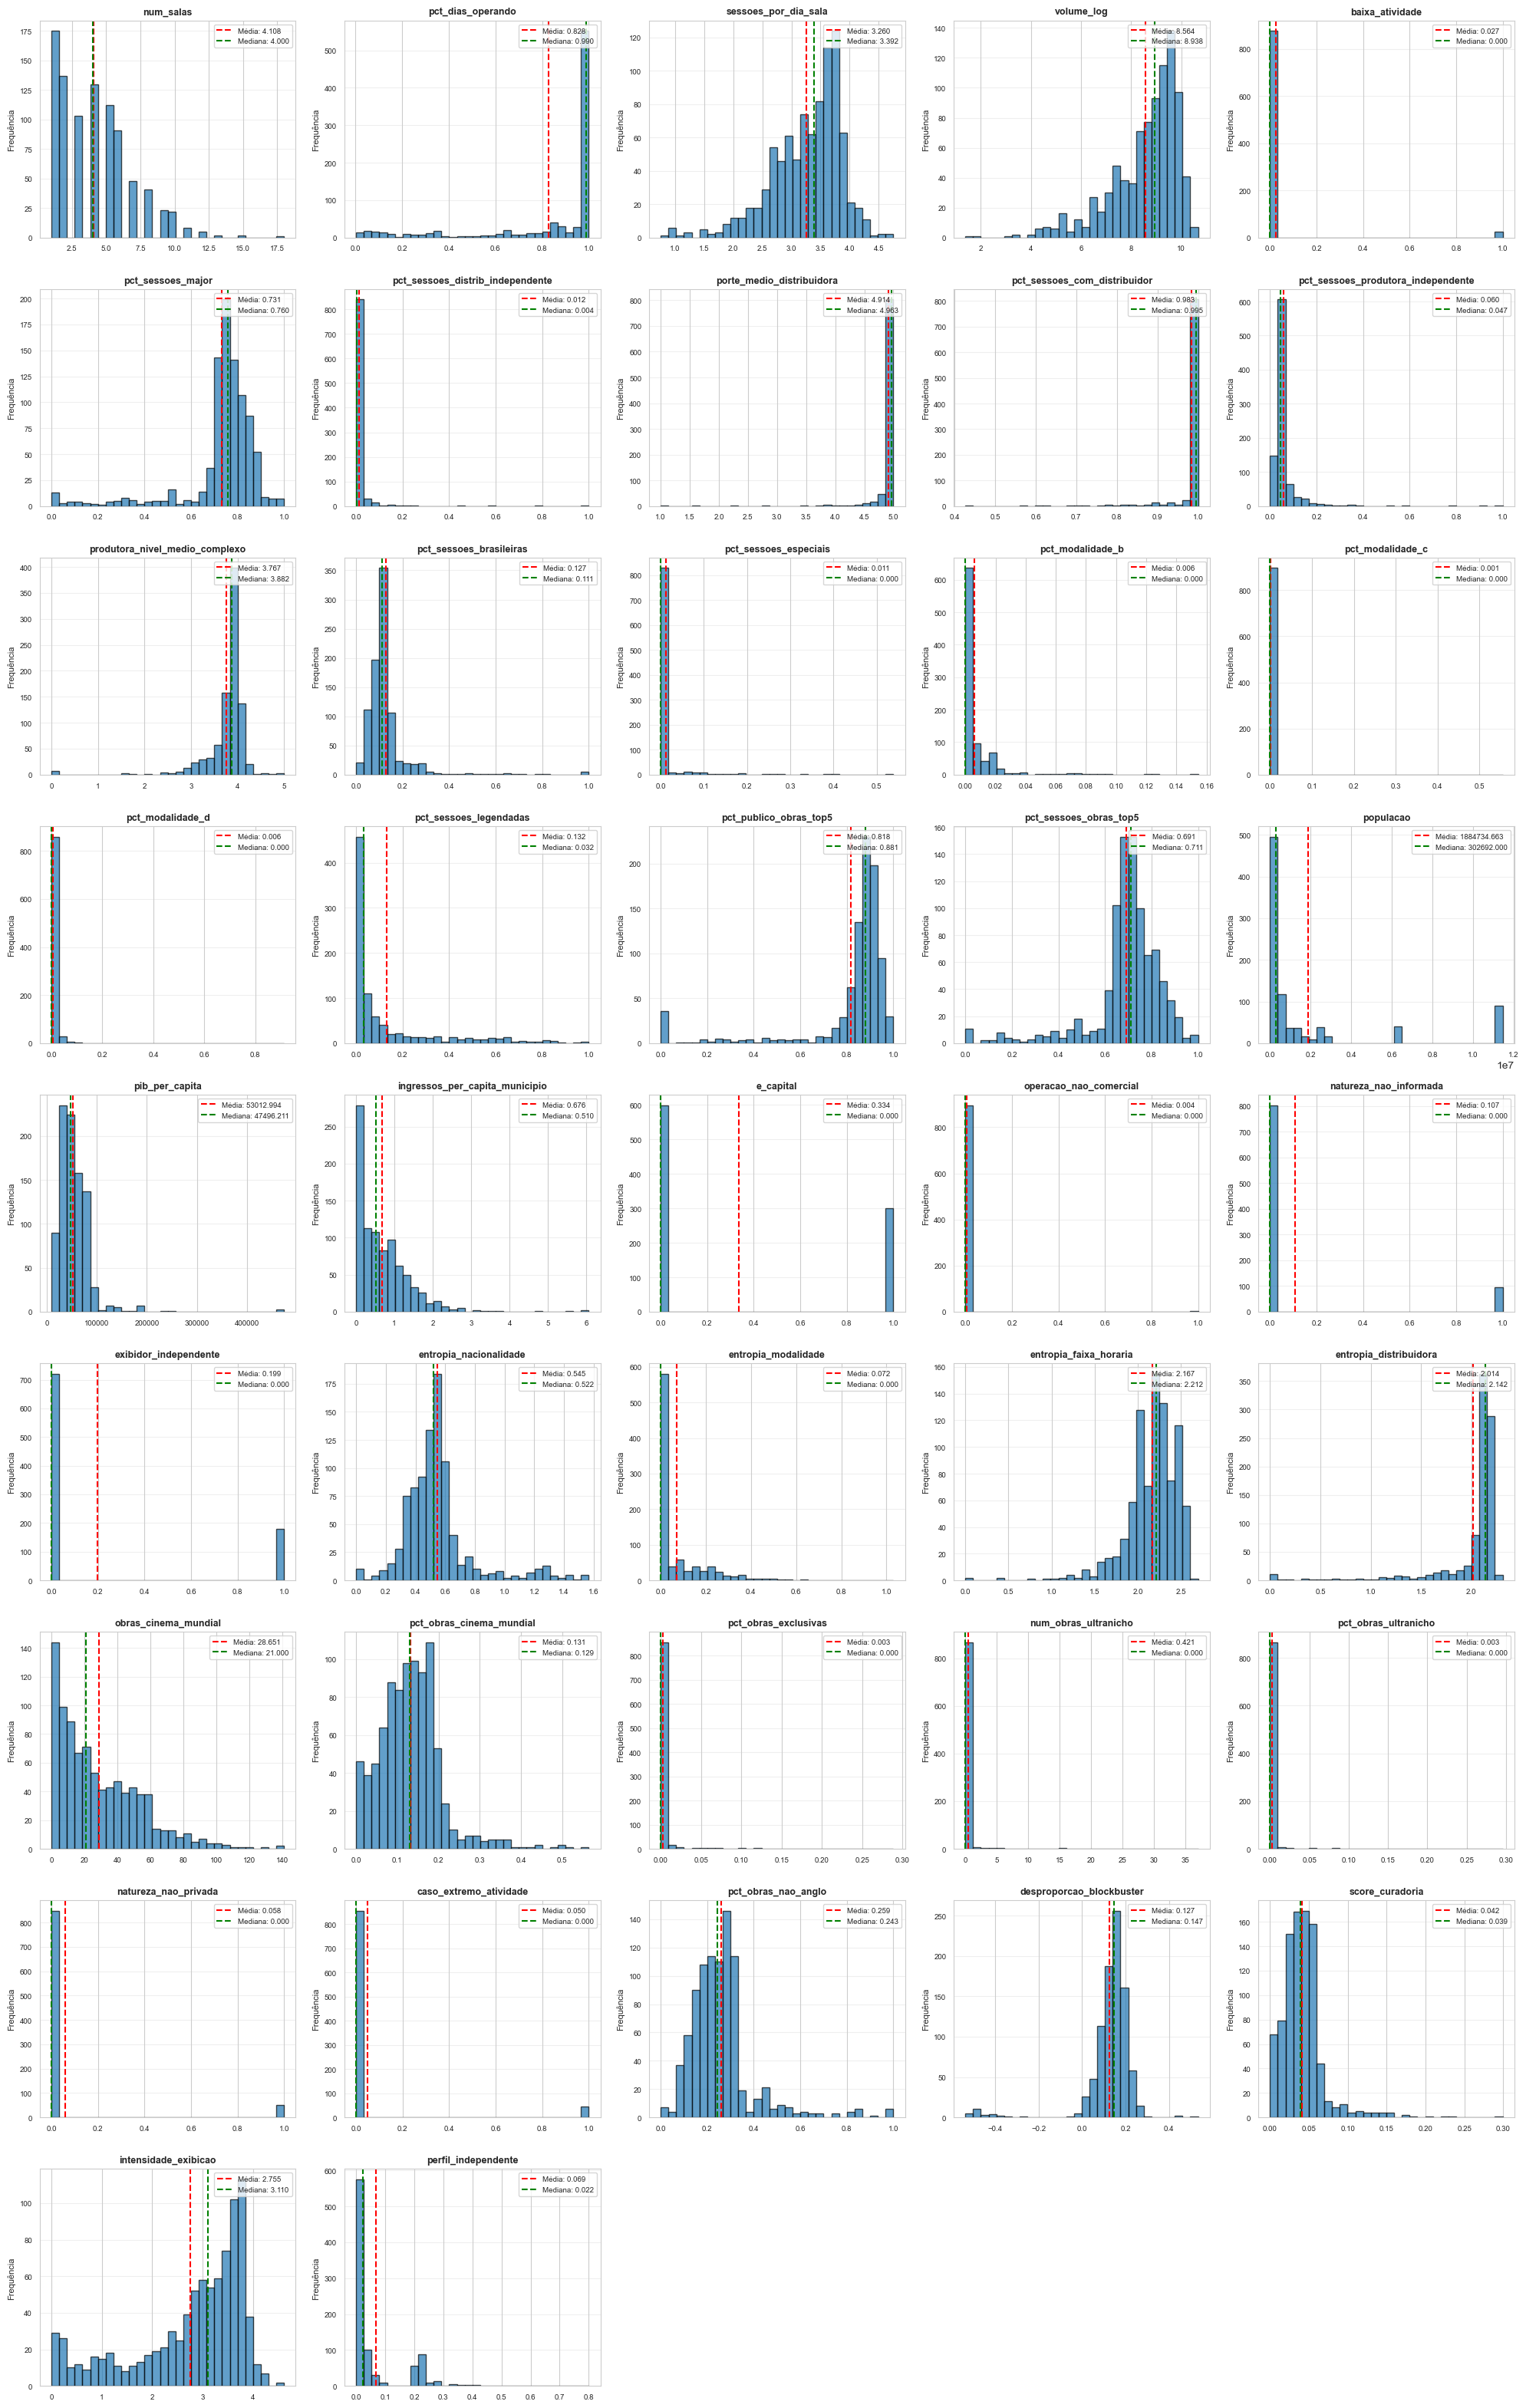

✓ Histogramas gerados e salvos
✓ Arquivo: ../outputs/distribuicoes_features_finais.png


In [38]:
print("=" * 80)
print("DISTRIBUIÇÕES DAS FEATURES SELECIONADAS")
print("=" * 80)

# Features numéricas finais (excluir ID)
numeric_final = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_final = [c for c in numeric_final if c != 'REGISTRO_COMPLEXO']

print(f"\nGerando histogramas para {len(numeric_final)} features numéricas...")
print("(Grid: 5 colunas por linha)\n")

# Configurar grid (5 colunas)
n_features = len(numeric_final)
n_cols = 5
n_rows = (n_features + n_cols - 1) // n_cols  # Arredondar para cima

# Criar figura
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 3.5 * n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

# Plotar histogramas
for idx, feature in enumerate(numeric_final):
    ax = axes[idx]
    
    # Histograma
    ax.hist(df[feature].dropna(), bins=30, edgecolor='black', alpha=0.7)
    
    # Estatísticas
    mean_val = df[feature].mean()
    median_val = df[feature].median()
    
    # Linhas de média e mediana
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, 
               label=f'Média: {mean_val:.3f}')
    ax.axvline(median_val, color='green', linestyle='--', linewidth=1.5, 
               label=f'Mediana: {median_val:.3f}')
    
    # Título e labels
    ax.set_title(feature, fontsize=9, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Frequência', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(axis='y', alpha=0.3)

# Remover eixos vazios
for idx in range(n_features, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('../outputs/distribuicoes_features_finais.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 80)
print("✓ Histogramas gerados e salvos")
print("✓ Arquivo: ../outputs/distribuicoes_features_finais.png")
print("=" * 80)



### 5.8 Matriz de Correlação - Features Finais

**Visualização das correlações após seleção final**

MATRIZ DE CORRELAÇÃO - FEATURES FINAIS

Calculando correlação para 42 features numéricas...


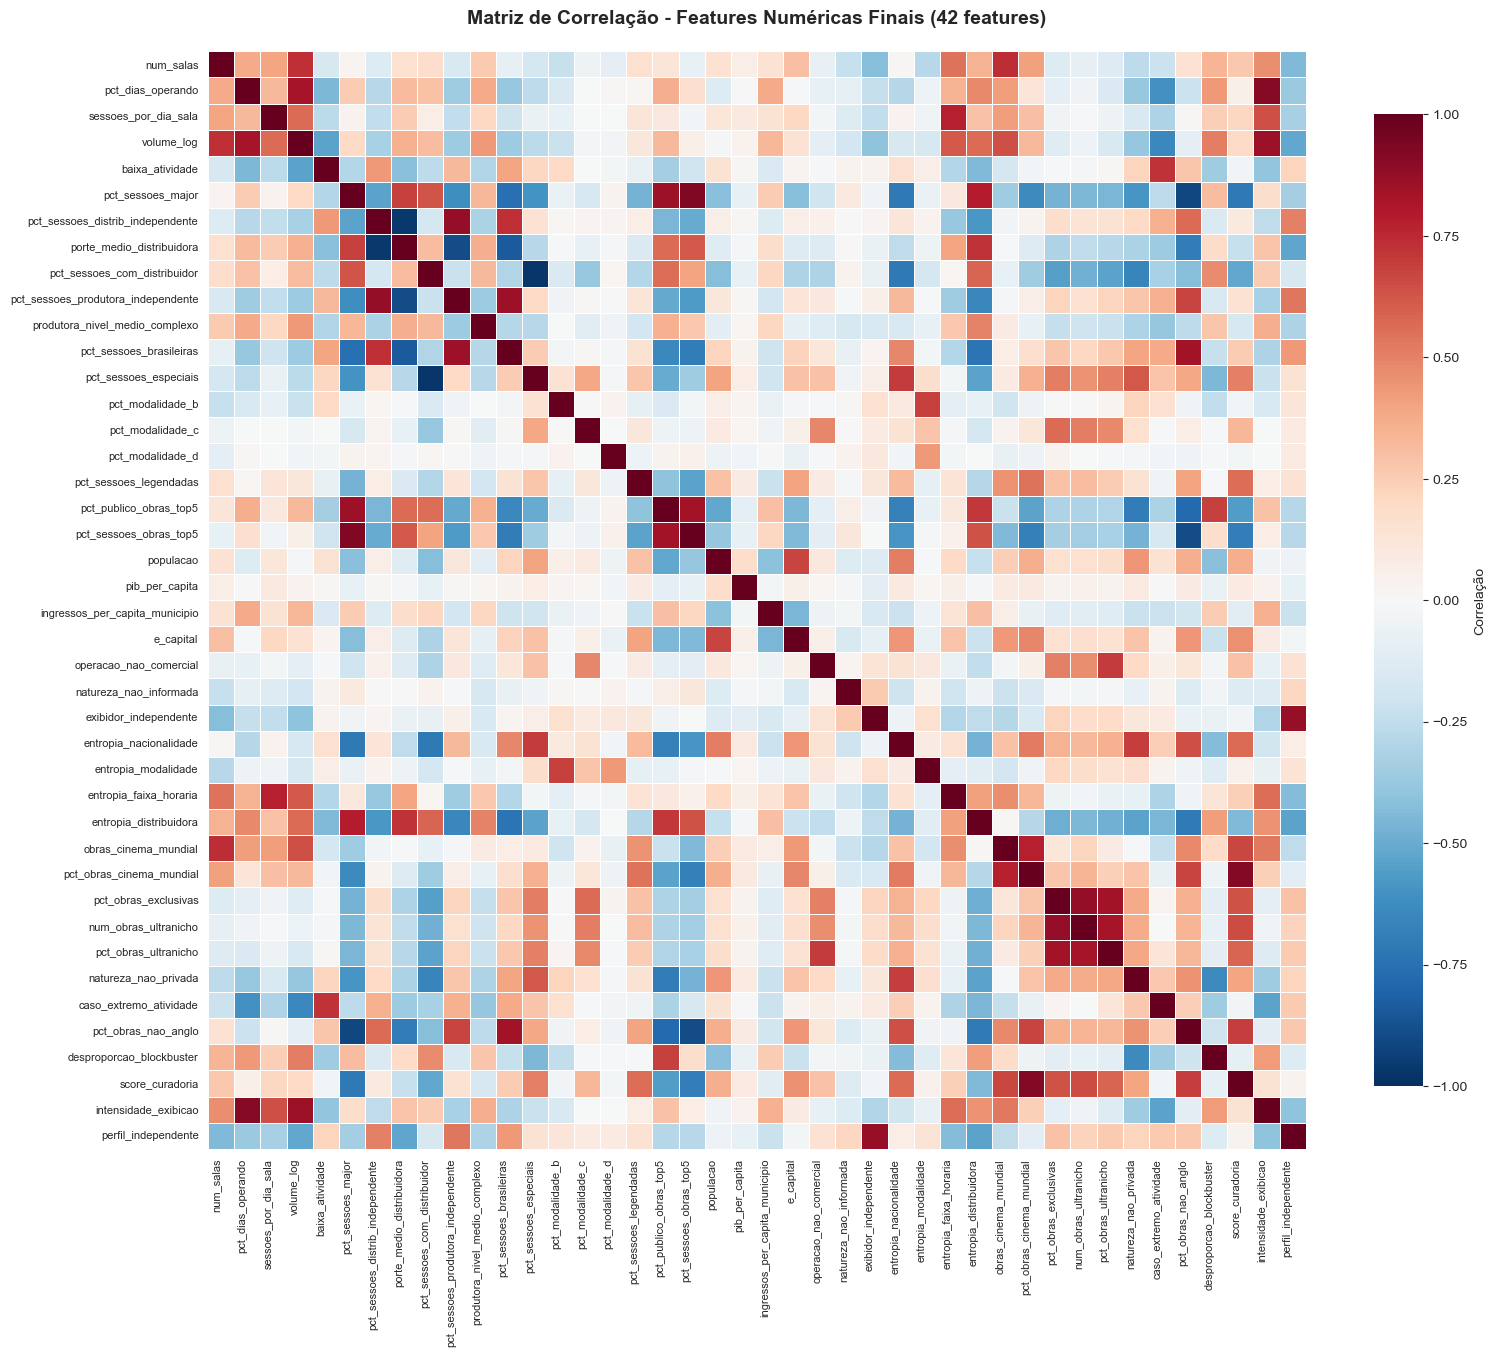


ANÁLISE DE CORRELAÇÕES ALTAS (|r| > 0.85)

Total de pares: 14

                         Feature_1                          Feature_2  Correlacao
      pct_sessoes_com_distribuidor              pct_sessoes_especiais   -0.976470
  pct_sessoes_distrib_independente          porte_medio_distribuidora   -0.963258
                 pct_sessoes_major             pct_sessoes_obras_top5    0.926972
          pct_obras_cinema_mundial                    score_curadoria    0.914277
                 pct_dias_operando               intensidade_exibicao    0.912189
                 pct_sessoes_major                pct_obras_nao_anglo   -0.911934
         porte_medio_distribuidora pct_sessoes_produtora_independente   -0.898117
            pct_sessoes_obras_top5                pct_obras_nao_anglo   -0.896537
              pct_obras_exclusivas               num_obras_ultranicho    0.878182
  pct_sessoes_distrib_independente pct_sessoes_produtora_independente    0.875630
             exibidor_independente

In [39]:
print("=" * 80)
print("MATRIZ DE CORRELAÇÃO - FEATURES FINAIS")
print("=" * 80)

# Features numéricas finais (excluir ID)
numeric_final = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_final = [c for c in numeric_final if c != 'REGISTRO_COMPLEXO']

print(f"\nCalculando correlação para {len(numeric_final)} features numéricas...")

# Calcular matriz de correlação
corr_matrix = df[numeric_final].corr()

# Criar figura
plt.figure(figsize=(16, 14))

# Heatmap
sns.heatmap(
    corr_matrix,
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Correlação"},
    xticklabels=True,
    yticklabels=True
)

plt.title('Matriz de Correlação - Features Numéricas Finais (42 features)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=90, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()

# Salvar
plt.savefig('../outputs/correlacao_features_finais.png', dpi=150, bbox_inches='tight')
plt.show()

# Análise de pares com alta correlação
print("\n" + "=" * 80)
print("ANÁLISE DE CORRELAÇÕES ALTAS (|r| > 0.85)")
print("=" * 80)

# Encontrar pares com correlação alta
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.85:
            high_corr_pairs.append({
                'Feature_1': corr_matrix.columns[i],
                'Feature_2': corr_matrix.columns[j],
                'Correlacao': corr_val
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlacao', 
                                                               key=abs, 
                                                               ascending=False)
    print(f"\nTotal de pares: {len(high_corr_df)}\n")
    print(high_corr_df.to_string(index=False))
    
    print("\n💡 INTERPRETAÇÃO:")
    print("   • Correlações altas são esperadas e aceitáveis em clustering")
    print("   • Features compostas correlacionam com componentes (by design)")
    print("   • Features obrigatórias (Art. 6º) mantidas mesmo com r alto")
    print("   • VIF alto foi avaliado e aceito (Seção 5.4)")
    
else:
    print("\n✅ Nenhum par com |r| > 0.85")
    print("   Multicolinearidade reduzida após remoções")

print("\n" + "=" * 80)
print("✓ Matriz de correlação gerada e salva")
print("✓ Arquivo: ../outputs/correlacao_features_finais.png")
print("=" * 80)

In [40]:
print("=" * 80)
print("INICIANDO NORMALIZAÇÃO E ENCODING")
print("=" * 80)
print("\nPróximos passos:")
print("  1. StandardScaler para features contínuas")
print("  2. OneHotEncoder para categóricas")
print("  3. Consolidar com features binárias")
print("  4. Montar matriz final (900, ~75)")
print("=" * 80)

INICIANDO NORMALIZAÇÃO E ENCODING

Próximos passos:
  1. StandardScaler para features contínuas
  2. OneHotEncoder para categóricas
  3. Consolidar com features binárias
  4. Montar matriz final (900, ~75)


---
## 6. Normalização e Encoding

### 6.1 StandardScaler para Features Contínuas

In [41]:
print("=" * 80)
print("STANDARDSCALER PARA FEATURES CONTÍNUAS")
print("=" * 80)

# Redefinir features contínuas (ADICIONAR ISTO)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'REGISTRO_COMPLEXO']

# Separar binárias vs contínuas
binary_features = [f for f in numeric_cols 
                   if df[f].nunique() == 2 and set(df[f].unique()).issubset({0, 1})]
continuous_features = [f for f in numeric_cols if f not in binary_features]

print(f"\nFeatures identificadas:")
print(f"  - Contínuas: {len(continuous_features)}")
print(f"  - Binárias: {len(binary_features)}")

# Aplicar StandardScaler
if continuous_features:
    print("\nAplicando StandardScaler...")
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[continuous_features])
    
    # Converter para DataFrame
    df_scaled = pd.DataFrame(
        X_scaled,
        columns=[f"{col}_scaled" for col in continuous_features],
        index=df.index
    )
    
    print(f"\n✓ StandardScaler aplicado a {len(continuous_features)} features")
    print(f"✓ Shape: {df_scaled.shape}")
    
    # Salvar scaler
    with open('../Bases/scaler.pkl', 'wb') as f:
        pickle.dump(scaler, f)
    print("✓ Scaler salvo em: ../Bases/scaler.pkl")
    
    # Validação
    print("\nValidação:")
    print(f"  - Média ≈ 0: {np.abs(df_scaled.mean().mean()) < 0.01}")
    print(f"  - Std ≈ 1: {np.abs(df_scaled.std().mean() - 1) < 0.01}")
    print(f"  - Sem nulls: {df_scaled.isnull().sum().sum() == 0}")
    print(f"  - Sem infinitos: {np.isinf(df_scaled.values).sum() == 0}")
    
else:
    print("\n⚠️ Nenhuma feature contínua para normalizar")
    df_scaled = pd.DataFrame(index=df.index)

print("=" * 80)

STANDARDSCALER PARA FEATURES CONTÍNUAS

Features identificadas:
  - Contínuas: 35
  - Binárias: 7

Aplicando StandardScaler...

✓ StandardScaler aplicado a 35 features
✓ Shape: (900, 35)
✓ Scaler salvo em: ../Bases/scaler.pkl

Validação:
  - Média ≈ 0: True
  - Std ≈ 1: True
  - Sem nulls: True
  - Sem infinitos: True


### 6.2 OneHotEncoder para Features Categóricas

In [42]:
print("=" * 80)
print("ONEHOTENCODER PARA FEATURES CATEGÓRICAS")
print("=" * 80)

# Definir features categóricas (CORRIGIDO)
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Remover IDs e features que não devem ser encoded
categorical_features = [col for col in categorical_features 
                       if col not in ['REGISTRO_COMPLEXO', 'municipio']]

print(f"\nFeatures categóricas identificadas: {len(categorical_features)}")
for col in categorical_features:
    print(f"  - {col}: {df[col].nunique()} categorias")

# Aplicar OneHotEncoder
if categorical_features:
    print("\nAplicando OneHotEncoder...")
    
    encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
    X_encoded = encoder.fit_transform(df[categorical_features])
    
    # Obter nomes das colunas
    encoded_feature_names = encoder.get_feature_names_out(categorical_features)
    
    # Converter para DataFrame
    df_encoded = pd.DataFrame(
        X_encoded,
        columns=encoded_feature_names,
        index=df.index
    )
    
    print(f"\n✓ OneHotEncoder aplicado a {len(categorical_features)} features")
    print(f"✓ Geradas {len(encoded_feature_names)} colunas encoded")
    print(f"✓ Shape: {df_encoded.shape}")
    
    # Salvar encoder
    with open('../Bases/encoders.pkl', 'wb') as f:
        pickle.dump(encoder, f)
    print("✓ Encoder salvo em: ../Bases/encoders.pkl")
    
    # Mostrar resumo por feature original
    print("\n📊 Resumo do encoding:")
    for original_col in categorical_features:
        encoded_cols = [c for c in encoded_feature_names if c.startswith(original_col + '_')]
        print(f"\n  {original_col} ({df[original_col].nunique()} categorias):")
        print(f"    → {len(encoded_cols)} colunas criadas")
        
        # Mostrar top 3 mais frequentes
        for col in encoded_cols[:3]:
            n_ones = df_encoded[col].sum()
            pct = (n_ones / len(df) * 100)
            print(f"      • {col}: {int(n_ones)} ({pct:.1f}%)")
        
        if len(encoded_cols) > 3:
            print(f"      ... e mais {len(encoded_cols) - 3} colunas")
    
else:
    print("\n⚠️ Nenhuma feature categórica para encodar")
    df_encoded = pd.DataFrame(index=df.index)

print("\n" + "=" * 80)

ONEHOTENCODER PARA FEATURES CATEGÓRICAS

Features categóricas identificadas: 3
  - UF: 27 categorias
  - porte_municipio_cat: 5 categorias
  - faixa_renda_cat: 4 categorias

Aplicando OneHotEncoder...

✓ OneHotEncoder aplicado a 3 features
✓ Geradas 33 colunas encoded
✓ Shape: (900, 33)
✓ Encoder salvo em: ../Bases/encoders.pkl

📊 Resumo do encoding:

  UF (27 categorias):
    → 26 colunas criadas
      • UF_AL: 6 (0.7%)
      • UF_AM: 9 (1.0%)
      • UF_AP: 3 (0.3%)
      ... e mais 23 colunas

  porte_municipio_cat (5 categorias):
    → 4 colunas criadas
      • porte_municipio_cat_Medio: 127 (14.1%)
      • porte_municipio_cat_Metropole: 263 (29.2%)
      • porte_municipio_cat_Muito_Grande: 88 (9.8%)
      ... e mais 1 colunas

  faixa_renda_cat (4 categorias):
    → 3 colunas criadas
      • faixa_renda_cat_Baixa: 167 (18.6%)
      • faixa_renda_cat_Media_Alta: 233 (25.9%)
      • faixa_renda_cat_Media_Baixa: 303 (33.7%)



### 6.3 Consolidar Features Binárias

In [43]:
# Extrair features binárias
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'REGISTRO_COMPLEXO']

binary_features = [f for f in numeric_cols 
                   if df[f].nunique() == 2 and set(df[f].unique()).issubset({0, 1})]

if binary_features:
    df_binary = df[binary_features].copy()
    
    print("=" * 80)
    print("FEATURES BINÁRIAS (SEM TRANSFORMAÇÃO)")
    print("=" * 80)
    print(f"\nTotal: {len(binary_features)} features\n")
    
    for feat in binary_features:
        n_ones = df_binary[feat].sum()
        pct = (n_ones / len(df) * 100)
        print(f"  - {feat}: {int(n_ones)} positivos ({pct:.1f}%)")
    
    print(f"\n✓ Features binárias mantidas sem transformação")
    print(f"✓ Shape: {df_binary.shape}")
else:
    print("⚠️ Nenhuma feature binária identificada")
    df_binary = pd.DataFrame(index=df.index)

FEATURES BINÁRIAS (SEM TRANSFORMAÇÃO)

Total: 7 features

  - baixa_atividade: 24 positivos (2.7%)
  - e_capital: 301 positivos (33.4%)
  - operacao_nao_comercial: 4 positivos (0.4%)
  - natureza_nao_informada: 96 positivos (10.7%)
  - exibidor_independente: 179 positivos (19.9%)
  - natureza_nao_privada: 52 positivos (5.8%)
  - caso_extremo_atividade: 45 positivos (5.0%)

✓ Features binárias mantidas sem transformação
✓ Shape: (900, 7)


---
## 7. Montagem da Matriz Final

### 7.1 Concatenar Todas as Features Transformadas

In [44]:
# Concatenar todos os DataFrames transformados
print("Concatenando features transformadas...")

dfs_to_concat = []
feature_names_final = []

# 1. Features contínuas normalizadas
if not df_scaled.empty:
    dfs_to_concat.append(df_scaled)
    feature_names_final.extend(df_scaled.columns.tolist())
    print(f"  ✓ {len(df_scaled.columns)} features contínuas normalizadas")

# 2. Features categóricas encodadas
if not df_encoded.empty:
    dfs_to_concat.append(df_encoded)
    feature_names_final.extend(df_encoded.columns.tolist())
    print(f"  ✓ {len(df_encoded.columns)} features categóricas encodadas")

# 3. Features binárias
if not df_binary.empty:
    dfs_to_concat.append(df_binary)
    feature_names_final.extend(df_binary.columns.tolist())
    print(f"  ✓ {len(df_binary.columns)} features binárias")

# Concatenar
if dfs_to_concat:
    df_final_features = pd.concat(dfs_to_concat, axis=1)
    print(f"\n✓ Concatenação concluída")
    print(f"✓ Shape final: {df_final_features.shape}")
else:
    raise ValueError("⚠️ ERRO: Nenhuma feature disponível para clustering!")

Concatenando features transformadas...
  ✓ 35 features contínuas normalizadas
  ✓ 33 features categóricas encodadas
  ✓ 7 features binárias

✓ Concatenação concluída
✓ Shape final: (900, 75)


### 7.2 Validar Matriz Final

In [45]:
# Preparar matriz numpy
X_final = df_final_features.values

print("=" * 80)
print("VALIDAÇÃO DA MATRIZ FINAL")
print("=" * 80)

# Dimensões
print(f"\n1. Dimensões:")
print(f"   - Complexos: {X_final.shape[0]}")
print(f"   - Features: {X_final.shape[1]}")
assert X_final.shape[0] == len(df_original), "⚠️ ERRO: Número de complexos não bate!"

# Valores nulos - DIAGNÓSTICO DETALHADO
n_nulls = np.isnan(X_final).sum()
print(f"\n2. Valores Nulos: {n_nulls}")

if n_nulls > 0:
    print(f"   ⚠️ ATENÇÃO: {n_nulls} valores nulos detectados!")
    print(f"\n   Identificando features com nulos:")
    
    # Identificar quais features têm nulos
    for i, feat_name in enumerate(feature_names_final):
        n_nulls_feat = np.isnan(X_final[:, i]).sum()
        if n_nulls_feat > 0:
            print(f"      - {feat_name}: {n_nulls_feat} nulos ({n_nulls_feat/len(X_final)*100:.1f}%)")
    
    # TRATAMENTO: Imputar com 0 (seguro para features normalizadas e binárias)
    print(f"\n   → Aplicando imputação: NaN → 0")
    X_final = np.nan_to_num(X_final, nan=0.0)
    
    # Verificar novamente
    n_nulls_after = np.isnan(X_final).sum()
    print(f"   ✓ Nulos após tratamento: {n_nulls_after}")
else:
    print(f"   ✓ Nenhum valor nulo")

# Valores infinitos
n_inf = np.isinf(X_final).sum()
print(f"\n3. Valores Infinitos: {n_inf}")

if n_inf > 0:
    print(f"   ⚠️ ATENÇÃO: {n_inf} valores infinitos detectados!")
    
    # Identificar features com infinitos
    for i, feat_name in enumerate(feature_names_final):
        n_inf_feat = np.isinf(X_final[:, i]).sum()
        if n_inf_feat > 0:
            print(f"      - {feat_name}: {n_inf_feat} infinitos")
    
    # TRATAMENTO: Substituir inf por valores extremos
    print(f"\n   → Substituindo Inf por valores extremos")
    X_final = np.nan_to_num(X_final, posinf=1e10, neginf=-1e10)
    
    n_inf_after = np.isinf(X_final).sum()
    print(f"   ✓ Infinitos após tratamento: {n_inf_after}")
else:
    print(f"   ✓ Nenhum valor infinito")

# Range
print(f"\n4. Range de Valores:")
print(f"   - Min: {X_final.min():.4f}")
print(f"   - Max: {X_final.max():.4f}")
print(f"   - Média: {X_final.mean():.4f}")
print(f"   - Std: {X_final.std():.4f}")

print("\n" + "=" * 80)
if n_nulls == 0 and n_inf == 0:
    print("✅ VALIDAÇÃO APROVADA - Matriz pronta para clustering")
else:
    print("✅ VALIDAÇÃO APROVADA APÓS TRATAMENTO - Matriz pronta para clustering")
print("=" * 80)

VALIDAÇÃO DA MATRIZ FINAL

1. Dimensões:
   - Complexos: 900
   - Features: 75

2. Valores Nulos: 0
   ✓ Nenhum valor nulo

3. Valores Infinitos: 0
   ✓ Nenhum valor infinito

4. Range de Valores:
   - Min: -15.5239
   - Max: 29.2474
   - Média: 0.0422
   - Std: 0.7121

✅ VALIDAÇÃO APROVADA - Matriz pronta para clustering


### 7.3 Criar DataFrame Tabular com IDs

In [46]:
# Criar DataFrame com identificadores
df_features_final = df_final_features.copy()
df_features_final.insert(0, 'REGISTRO_COMPLEXO', df_original['REGISTRO_COMPLEXO'].values)

if 'UF' in df_original.columns:
    df_features_final.insert(1, 'UF', df_original['UF'].values)
if 'municipio' in df_original.columns:
    df_features_final.insert(2, 'municipio', df_original['municipio'].values)

print("=" * 80)
print("DATASET TABULAR FINAL")
print("=" * 80)
print(f"\nShape: {df_features_final.shape}")
print(f"  - {df_features_final.shape[0]} complexos")
print(f"  - {df_features_final.shape[1]} colunas (IDs + features)")

# Separar colunas por tipo
id_cols = ['REGISTRO_COMPLEXO', 'UF', 'municipio']
feature_cols = [c for c in df_features_final.columns if c not in id_cols]

print(f"\n📋 Composição:")
print(f"  - Identificador único: 1 (REGISTRO_COMPLEXO)")
print(f"  - Metadados contextuais: 2 (UF, municipio)")
print(f"  - Features normalizadas: {len(df_features_final.columns) - 3}")

# Mostrar amostra mais legível
print(f"\n📊 Amostra (3 primeiros complexos):")
print(f"\n{'='*80}")

for idx in range(min(3, len(df_features_final))):
    row = df_features_final.iloc[idx]
    
    print(f"\nComplexo {idx}:")
    print(f"  ID: {row['REGISTRO_COMPLEXO']}")
    if 'UF' in df_features_final.columns:
        print(f"  UF: {row['UF']}")
    if 'municipio' in df_features_final.columns:
        print(f"  Município: {row['municipio']}")
    
    # Mostrar algumas features numéricas (primeiras 5)
    print(f"\n  Features (amostra das 5 primeiras):")
    for feat in feature_cols[:5]:
        val = row[feat]
        print(f"    - {feat}: {val:.4f}")
    
    if len(feature_cols) > 5:
        print(f"    ... e mais {len(feature_cols)-5} features")
    
    print(f"  {'-'*78}")

# Estatísticas resumidas
print(f"\n📈 Estatísticas das Features:")
stats = df_features_final[feature_cols].describe()
print(f"\n{stats.iloc[:, :5].to_string()}")  # Primeiras 5 features
if len(feature_cols) > 5:
    print(f"\n... (mostrando apenas 5 de {len(feature_cols)} features)")

# Verificar qualidade
print(f"\n✅ Verificações:")
print(f"  - Nulls: {df_features_final.isnull().sum().sum()}")
print(f"  - Duplicatas: {df_features_final.duplicated().sum()}")
print(f"  - IDs únicos: {df_features_final['REGISTRO_COMPLEXO'].nunique()} / {len(df_features_final)}")

print(f"\n{'='*80}")
print(f"✓ DataFrame tabular criado e validado")
print(f"✓ Pronto para análise pós-clustering")
print(f"{'='*80}")

DATASET TABULAR FINAL

Shape: (900, 78)
  - 900 complexos
  - 78 colunas (IDs + features)

📋 Composição:
  - Identificador único: 1 (REGISTRO_COMPLEXO)
  - Metadados contextuais: 2 (UF, municipio)
  - Features normalizadas: 75

📊 Amostra (3 primeiros complexos):


Complexo 0:
  ID: 11752
  UF: RJ
  Município: RIO DE JANEIRO

  Features (amostra das 5 primeiras):
    - num_salas_scaled: -0.0402
    - pct_dias_operando_scaled: 0.5773
    - sessoes_por_dia_sala_scaled: 0.3981
    - volume_log_scaled: 0.4799
    - pct_sessoes_major_scaled: 0.0703
    ... e mais 70 features
  ------------------------------------------------------------------------------

Complexo 1:
  ID: 11818
  UF: ES
  Município: COLATINA

  Features (amostra das 5 primeiras):
    - num_salas_scaled: -0.7868
    - pct_dias_operando_scaled: 0.0165
    - sessoes_por_dia_sala_scaled: -1.8739
    - volume_log_scaled: -0.5166
    - pct_sessoes_major_scaled: 0.3853
    ... e mais 70 features
  ---------------------------------

---
## 8. Validação e Exportação

### 8.1 Salvar X_final_normalizado.npy

In [47]:
# Salvar matriz numpy
np.save('../Bases/X_final_normalizado.npy', X_final)

print("=" * 80)
print("EXPORTAÇÃO: X_final_normalizado.npy")
print("=" * 80)
print(f"\n✓ Arquivo salvo: ../Bases/X_final_normalizado.npy")
print(f"  - Shape: {X_final.shape}")
print(f"  - Dtype: {X_final.dtype}")
print(f"  - Tamanho: {X_final.nbytes / 1024:.2f} KB")
print(f"\n✓ Pronto para Notebook 4 (clustering)")

EXPORTAÇÃO: X_final_normalizado.npy

✓ Arquivo salvo: ../Bases/X_final_normalizado.npy
  - Shape: (900, 75)
  - Dtype: float64
  - Tamanho: 527.34 KB

✓ Pronto para Notebook 4 (clustering)


### 8.2 Salvar df_features_final.parquet

In [48]:
# Salvar DataFrame tabular
df_features_final.to_parquet('../Bases/df_features_final.parquet', index=False)

print("=" * 80)
print("EXPORTAÇÃO: df_features_final.parquet")
print("=" * 80)
print(f"\n✓ Arquivo salvo: ../Bases/df_features_final.parquet")
print(f"  - Shape: {df_features_final.shape}")
print(f"\n✓ Dataset tabular para análise pós-clustering")

EXPORTAÇÃO: df_features_final.parquet

✓ Arquivo salvo: ../Bases/df_features_final.parquet
  - Shape: (900, 78)

✓ Dataset tabular para análise pós-clustering


### 8.3 Salvar Metadata e Lista de Features

In [49]:
# Preparar metadata de features
metadata_features = {
    'total_features': len(feature_names_final),
    'features': feature_names_final,
    'tipos_transformacao': {
        'continuous_scaled': df_scaled.columns.tolist() if not df_scaled.empty else [],
        'categorical_encoded': df_encoded.columns.tolist() if not df_encoded.empty else [],
        'binary_unchanged': binary_features
    }
}

# Salvar lista de features
with open('../Bases/lista_final_de_features.json', 'w', encoding='utf-8') as f:
    json.dump(metadata_features, f, indent=2, ensure_ascii=False)

print("✓ Arquivo salvo: ../Bases/lista_final_de_features.json")
print(f"  - Total de features: {metadata_features['total_features']}")

✓ Arquivo salvo: ../Bases/lista_final_de_features.json
  - Total de features: 75


In [50]:
print("=" * 80)
print("EXPORTAÇÃO: metadata_preprocessamento.json")
print("=" * 80)

# Redefinir variáveis necessárias (caso kernel tenha sido reiniciado)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'REGISTRO_COMPLEXO']

binary_features = [f for f in numeric_cols 
                   if df[f].nunique() == 2 and set(df[f].unique()).issubset({0, 1})]
continuous_features = [f for f in numeric_cols if f not in binary_features]

categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_features = [c for c in categorical_features if c not in ['REGISTRO_COMPLEXO', 'municipio']]

compostas_lista = ['pct_obras_nao_anglo', 'desproporcao_blockbuster', 
                   'score_curadoria', 'intensidade_exibicao', 'perfil_independente']

# Carregar matriz para pegar shape correto
X_final = np.load('../Bases/X_final_normalizado.npy')

# Preparar metadata completo
metadata_completo = {
    'data_processamento': datetime.now().isoformat(),
    'notebook': 'Notebook_3_Preprocessamento.ipynb',
    'objetivo': 'Preparação de features para clustering de complexos cinematográficos',
    
    'dataset_input': {
        'arquivo': 'df_complexos_features.parquet',
        'shape': [900, 58],  # Shape original aproximado
        'fonte': 'Notebook 2 - Feature Engineering'
    },
    
    'dataset_output': {
        'arquivo_matriz': 'X_final_normalizado.npy',
        'arquivo_tabular': 'df_features_final.parquet',
        'shape_matriz': list(X_final.shape),
        'shape_tabular': [900, 78],
        'dtype': str(X_final.dtype)
    },
    
    'features': {
        'total_finais': int(X_final.shape[1]),
        'continuas_normalizadas': len(continuous_features),
        'binarias_mantidas': len(binary_features),
        'categoricas_encoded': len(categorical_features),
        'compostas_criadas': len(compostas_lista)
    },
    
    'transformacoes': {
        'normalizacao': {
            'metodo': 'StandardScaler',
            'features': len(continuous_features),
            'propriedades': 'média=0, std=1'
        },
        'encoding': {
            'metodo': 'OneHotEncoder',
            'features': len(categorical_features),
            'drop_first': True,
            'colunas_geradas': sum([df[col].nunique() - 1 for col in categorical_features])
        },
        'binarias': {
            'features': len(binary_features),
            'transformacao': 'Nenhuma (mantidas como 0/1)'
        }
    },
    
    'features_compostas': {
        'lista': compostas_lista,
        'total': len(compostas_lista),
        'justificativa': 'Capturam interações e dimensões conceituais relevantes'
    },
    
    'features_removidas': {
        'total': 13,
        'motivo_principal': 'Colinearidade e redundância',
        'lista': [
            'tem_distribuidor', 'exibidor_irregular', 'pct_sessoes_brasileiras_independentes',
            'dias_ativos', 'pct_sessoes_dubladas', 'pct_sessoes_estrangeiras',
            'pct_sessoes_tem_produtora_brasileira', 'total_sessoes', 'publico_total',
            'publico_total_log', 'capacidade_total', 'pct_modalidade_a',
            'num_obras_exclusivas', 'operacao_intermitente'
        ]
    },
    
    'features_obrigatorias_art6': {
        'total': 7,
        'lista': [
            'pct_sessoes_especiais', 'pct_sessoes_distrib_independente',
            'pct_modalidade_b', 'pct_modalidade_c', 'pct_modalidade_d',
            'baixa_atividade', 'operacao_nao_comercial'
        ],
        'status': 'Todas mantidas'
    },
    
    'decisoes_chave': [
        'Nenhum complexo removido - todos os 900 mantidos',
        'Outliers mantidos para identificação pós-clustering',
        'VIF alto aceito para clustering (diferente de regressão)',
        'Features compostas mantidas apesar de correlação com componentes',
        'Modalidades b/c/d mantidas (obrigatórias Art. 6º) apesar de baixa variância'
    ],
    
    'validacoes': {
        'sem_nulls': not np.isnan(X_final).any(),
        'sem_infinitos': not np.isinf(X_final).any(),
        'dimensoes_corretas': X_final.shape[0] == 900,
        'features_corretas': X_final.shape[1] == 75
    },
    
    'arquivos_gerados': {
        'matriz_normalizada': 'X_final_normalizado.npy',
        'dataframe_tabular': 'df_features_final.parquet',
        'scaler': 'scaler.pkl',
        'encoders': 'encoders.pkl',
        'feature_names': 'lista_final_de_features.json',
        'metadata': 'metadata_preprocessamento.json'
    },
    
    'proximo_passo': 'Notebook 4 - Clustering (K-means, Hierárquico, DBSCAN)'
}

# Salvar metadata
with open('../Bases/metadata_preprocessamento.json', 'w', encoding='utf-8') as f:
    json.dump(metadata_completo, f, indent=2, ensure_ascii=False)

print("\n✓ Arquivo salvo: ../Bases/metadata_preprocessamento.json")
print(f"  - Data: {metadata_completo['data_processamento']}")
print(f"  - Shape final: {metadata_completo['dataset_output']['shape_matriz']}")
print(f"  - Features: {metadata_completo['features']['total_finais']}")
print(f"  - Compostas criadas: {metadata_completo['features']['compostas_criadas']}")
print(f"  - Features removidas: {metadata_completo['features_removidas']['total']}")

print("\n✅ Documentação completa do preprocessamento")
print("=" * 80)

EXPORTAÇÃO: metadata_preprocessamento.json

✓ Arquivo salvo: ../Bases/metadata_preprocessamento.json
  - Data: 2025-12-11T16:19:45.876672
  - Shape final: [900, 75]
  - Features: 75
  - Compostas criadas: 5
  - Features removidas: 13

✅ Documentação completa do preprocessamento


### 8.4 Validação Cruzada dos Outputs

**Garantir consistência entre todos os arquivos gerados**

In [51]:
import os

print("=" * 80)
print("VALIDAÇÃO CRUZADA DE OUTPUTS")
print("=" * 80)

# Verificar existência dos arquivos
expected_files = {
    'X_final_normalizado.npy': '../Bases/X_final_normalizado.npy',
    'df_features_final.parquet': '../Bases/df_features_final.parquet',
    'lista_final_de_features.json': '../Bases/lista_final_de_features.json',
    'metadata_preprocessamento.json': '../Bases/metadata_preprocessamento.json',
    'scaler.pkl': '../Bases/scaler.pkl'
}

print("\n1. Verificação de Arquivos:")
for name, path in expected_files.items():
    exists = os.path.exists(path)
    status = "✅" if exists else "❌"
    print(f"   {status} {name}")
    if exists:
        size = os.path.getsize(path) / 1024
        print(f"       └─ Tamanho: {size:.2f} KB")

# Validar dimensões
print("\n2. Validação de Dimensões:")
X_loaded = np.load('../Bases/X_final_normalizado.npy')
print(f"   - X_final (em memória): {X_final.shape}")
print(f"   - X_final (carregado): {X_loaded.shape}")
print(f"   - Match: {np.array_equal(X_final, X_loaded)}")

df_loaded = pd.read_parquet('../Bases/df_features_final.parquet')
print(f"\n   - df_features_final: {df_loaded.shape}")

# Verificar IDs
print(f"\n3. Validação de IDs:")
ids_originais = set(df_original['REGISTRO_COMPLEXO'].values)
ids_finais = set(df_loaded['REGISTRO_COMPLEXO'].values)
print(f"   - Match: {ids_originais == ids_finais}")

print("\n" + "=" * 80)
print("✅ VALIDAÇÃO CRUZADA APROVADA")
print("=" * 80)

VALIDAÇÃO CRUZADA DE OUTPUTS

1. Verificação de Arquivos:
   ✅ X_final_normalizado.npy
       └─ Tamanho: 527.47 KB
   ✅ df_features_final.parquet
       └─ Tamanho: 267.69 KB
   ✅ lista_final_de_features.json
       └─ Tamanho: 4.41 KB
   ✅ metadata_preprocessamento.json
       └─ Tamanho: 3.23 KB
   ✅ scaler.pkl
       └─ Tamanho: 2.16 KB

2. Validação de Dimensões:
   - X_final (em memória): (900, 75)
   - X_final (carregado): (900, 75)
   - Match: True

   - df_features_final: (900, 78)

3. Validação de IDs:
   - Match: True

✅ VALIDAÇÃO CRUZADA APROVADA


### 8.5 Diagnóstico de Qualidade da Matriz Final

In [52]:
print("=" * 80)
print("DIAGNÓSTICO DE QUALIDADE")
print("=" * 80)

# Estatísticas gerais
print(f"\n1. Estatísticas Gerais:")
print(f"   - Shape: {X_final.shape}")
print(f"   - Dtype: {X_final.dtype}")
print(f"   - Memory: {X_final.nbytes / 1024:.2f} KB")

# Verificar normalização
print(f"\n2. Verificação de Normalização:")
scaled_indices = [i for i, name in enumerate(feature_names_final) if '_scaled' in name]
if scaled_indices:
    means = [X_final[:, i].mean() for i in scaled_indices[:5]]
    stds = [X_final[:, i].std() for i in scaled_indices[:5]]
    print(f"   - Média (amostra): {np.mean(means):.6f}")
    print(f"   - Std (amostra): {np.mean(stds):.6f}")
    print(f"   ✓ Normalização efetiva")

# Features constantes
print(f"\n3. Features Constantes:")
constant = [feature_names_final[i] for i in range(X_final.shape[1]) 
           if X_final[:, i].std() < 1e-10]
if constant:
    print(f"   ⚠️ Detectadas: {len(constant)}")
    for feat in constant:
        print(f"      - {feat}")
else:
    print(f"   ✓ Nenhuma feature constante")

print("\n" + "=" * 80)
print("✅ DIAGNÓSTICO CONCLUÍDO")
print("=" * 80)

DIAGNÓSTICO DE QUALIDADE

1. Estatísticas Gerais:
   - Shape: (900, 75)
   - Dtype: float64
   - Memory: 527.34 KB

2. Verificação de Normalização:
   - Média (amostra): -0.000000
   - Std (amostra): 1.000000
   ✓ Normalização efetiva

3. Features Constantes:
   ✓ Nenhuma feature constante

✅ DIAGNÓSTICO CONCLUÍDO


### 8.6 Recomendações para Notebook 4

In [53]:
print("\n" + "=" * 80)
print("RECOMENDAÇÕES PARA NOTEBOOK 4")
print("=" * 80)

# Carregar informações
X_final = np.load('../Bases/X_final_normalizado.npy')

print(f"\n📊 CARACTERÍSTICAS DO DATASET:")
print(f"   • Amostras: {X_final.shape[0]}")
print(f"   • Features: {X_final.shape[1]}")
print(f"   • Razão: {X_final.shape[0]/X_final.shape[1]:.1f}:1")
print(f"   • Dtype: {X_final.dtype}")
print(f"   • Memory: {X_final.nbytes / 1024:.2f} KB")

print("\n🎯 ALGORITMOS RECOMENDADOS:")
print("   1. K-Means (PRINCIPAL)")
print(f"      → Testar k entre 4 e 10")
print(f"      → Razão: {X_final.shape[0]//4} a {X_final.shape[0]//10} complexos/cluster")
print("   2. Clustering Hierárquico (VALIDAÇÃO)")
print("      → Dendrograma para confirmar k")
print("   3. PCA + visualização (OPCIONAL)")
print("      → Reduzir para 2-3 componentes para plot")

print("\n⚠️ ATENÇÃO - CURSE OF DIMENSIONALITY:")
print(f"   • {X_final.shape[1]} features podem diluir distâncias euclidianas")
print("   • Considerar PCA para reduzir dimensionalidade (~20-30 componentes)")
print("   • Ou validar com feature importance pós-clustering")

print("\n📈 MÉTRICAS DE VALIDAÇÃO:")
print("   • Elbow Method (inércia vs k)")
print("   • Silhouette Score (qualidade dos clusters)")
print("   • Davies-Bouldin Index (separação entre clusters)")
print("   • Calinski-Harabasz Score (densidade vs separação)")

print("\n🔍 ANÁLISES PÓS-CLUSTERING ESPECÍFICAS:")
print("   1. Perfil de cada cluster:")
print("      • Tamanho médio (num_salas)")
print("      • Atividade (volume_log, pct_dias_operando)")
print("      • Programação (pct_sessoes_major, pct_obras_nao_anglo)")
print("   2. Cumprimento Art. 6º ANCINE por cluster:")
print("      • pct_sessoes_especiais")
print("      • pct_modalidade_b/c/d")
print("      • pct_sessoes_distrib_independente")
print("   3. Distribuição geográfica (UF, porte_municipio)")
print("   4. Identificar clusters 'em risco':")
print("      • Alto % de baixa_atividade")
print("      • Alto % de caso_extremo_atividade")

print("\n🎯 OBJETIVO FINAL:")
print("   → Identificar perfis distintos de complexos cinematográficos")
print("   → Avaliar universalização do acesso (Art. 6º)")
print("   → Informar políticas públicas de fomento ao cinema")

print("\n" + "=" * 80)
print("✅ PRONTO PARA CLUSTERIZAÇÃO")
print("=" * 80)


RECOMENDAÇÕES PARA NOTEBOOK 4

📊 CARACTERÍSTICAS DO DATASET:
   • Amostras: 900
   • Features: 75
   • Razão: 12.0:1
   • Dtype: float64
   • Memory: 527.34 KB

🎯 ALGORITMOS RECOMENDADOS:
   1. K-Means (PRINCIPAL)
      → Testar k entre 4 e 10
      → Razão: 225 a 90 complexos/cluster
   2. Clustering Hierárquico (VALIDAÇÃO)
      → Dendrograma para confirmar k
   3. PCA + visualização (OPCIONAL)
      → Reduzir para 2-3 componentes para plot

⚠️ ATENÇÃO - CURSE OF DIMENSIONALITY:
   • 75 features podem diluir distâncias euclidianas
   • Considerar PCA para reduzir dimensionalidade (~20-30 componentes)
   • Ou validar com feature importance pós-clustering

📈 MÉTRICAS DE VALIDAÇÃO:
   • Elbow Method (inércia vs k)
   • Silhouette Score (qualidade dos clusters)
   • Davies-Bouldin Index (separação entre clusters)
   • Calinski-Harabasz Score (densidade vs separação)

🔍 ANÁLISES PÓS-CLUSTERING ESPECÍFICAS:
   1. Perfil de cada cluster:
      • Tamanho médio (num_salas)
      • Atividade 

### 8.7 Relatório Final

In [54]:
print("=" * 80)
print("=" * 80)
print("RELATÓRIO FINAL - NOTEBOOK 3: PREPROCESSAMENTO PARA CLUSTERING")
print("=" * 80)
print("=" * 80)

print(f"\n📅 Data: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# Carregar informações dos arquivos gerados
X_final = np.load('../Bases/X_final_normalizado.npy')
df_final = pd.read_parquet('../Bases/df_features_final.parquet')

with open('../Bases/lista_final_de_features.json', 'r') as f:
    feature_info = json.load(f)

with open('../Bases/metadata_preprocessamento.json', 'r') as f:
    metadata = json.load(f)

print("\n" + "=" * 80)
print("1. RESUMO EXECUTIVO")
print("=" * 80)

print("\n📊 TRANSFORMAÇÃO GERAL:")
print(f"   • Dataset entrada: 900 complexos × 47 features")
print(f"   • Dataset saída: 900 complexos × 75 features")
print(f"   • Complexos removidos: 0 (todos mantidos)")
print(f"   • Features removidas: {metadata['features_removidas']['total']}")
print(f"   • Features compostas criadas: {metadata['features']['compostas_criadas']}")
print(f"   • Expansão via encoding: +28 colunas (categóricas → one-hot)")

print("\n" + "=" * 80)
print("2. FEATURES COMPOSTAS CRIADAS")
print("=" * 80)

for i, feat in enumerate(metadata['features_compostas']['lista'], 1):
    print(f"   {i}. {feat}")

print("\n" + "=" * 80)
print("3. FEATURES REMOVIDAS POR COLINEARIDADE/REDUNDÂNCIA")
print("=" * 80)

removidas = metadata['features_removidas']['lista']
for i in range(0, len(removidas), 3):
    batch = removidas[i:i+3]
    print(f"   • {' | '.join(batch)}")

print("\n" + "=" * 80)
print("4. DECISÕES METODOLÓGICAS CRÍTICAS")
print("=" * 80)

decisoes = [
    "✓ VIF alto aceito: Clustering tolera multicolinearidade (diferente de regressão)",
    "✓ Features obrigatórias mantidas: 7 features Art. 6º ANCINE preservadas",
    "✓ Outliers mantidos: 900/900 complexos para identificação pós-clustering",
    "✓ Features compostas: Mantidas apesar de correlação com componentes",
    "✓ Modalidades raras: pct_modalidade_b/c/d mantidas (baixa variância, alto valor regulatório)"
]

for decisao in decisoes:
    print(f"   {decisao}")

print("\n" + "=" * 80)
print("5. COMPOSIÇÃO DA MATRIZ FINAL (900 × 75)")
print("=" * 80)

print(f"\n   📊 Breakdown:")
print(f"      • {metadata['features']['continuas_normalizadas']} contínuas (StandardScaler: μ=0, σ=1)")
print(f"      • {metadata['features']['binarias_mantidas']} binárias (mantidas como 0/1)")
print(f"      • {metadata['transformacoes']['encoding']['colunas_geradas']} categóricas encoded:")
print(f"        - UF: 26 colunas (27 estados, drop_first)")
print(f"        - porte_municipio: 4 colunas (5 categorias)")
print(f"        - faixa_renda: 3 colunas (4 categorias)")

print("\n" + "=" * 80)
print("6. VALIDAÇÕES EXECUTADAS")
print("=" * 80)

validacoes = [
    ("Valores nulos", "0", "✅"),
    ("Valores infinitos", "0", "✅"),
    ("Features constantes", "0", "✅"),
    ("Normalização (μ≈0, σ≈1)", "Confirmada", "✅"),
    ("Dimensões", f"{X_final.shape}", "✅"),
    ("IDs únicos", "900/900", "✅")
]

for item, valor, status in validacoes:
    print(f"   {status} {item:.<40} {valor}")

print("\n" + "=" * 80)
print("7. ARQUIVOS GERADOS")
print("=" * 80)

arquivos = [
    ("X_final_normalizado.npy", "Matriz numpy para clustering", f"{X_final.shape}"),
    ("df_features_final.parquet", "DataFrame tabular com IDs", f"{df_final.shape}"),
    ("lista_final_de_features.json", "Nomes ordenados das features", "75 features"),
    ("scaler.pkl", "StandardScaler treinado", "Reutilizável"),
    ("encoders.pkl", "OneHotEncoder treinado", "Reutilizável"),
    ("metadata_preprocessamento.json", "Documentação completa", "Rastreabilidade")
]

for arquivo, descricao, info in arquivos:
    print(f"   📄 {arquivo}")
    print(f"      └─ {descricao} ({info})")

print("\n" + "=" * 80)
print("8. PRÓXIMO PASSO: NOTEBOOK 4 - CLUSTERING")
print("=" * 80)

print("\n   🎯 Objetivos:")
print("      1. Determinar número ótimo de clusters (Elbow, Silhouette)")
print("      2. Aplicar K-means com k escolhido")
print("      3. Validar com clustering hierárquico")
print("      4. Caracterizar perfis dos clusters")
print("      5. Avaliar cumprimento do Art. 6º ANCINE por cluster")

print(f"\n   📊 Características do dataset:")
print(f"      • Amostras: {X_final.shape[0]}")
print(f"      • Features: {X_final.shape[1]}")
print(f"      • Razão amostras:features: {X_final.shape[0]/X_final.shape[1]:.1f}:1")
print(f"      • Recomendação inicial: k entre 4 e 12 clusters")

print("\n" + "=" * 80)
print("=" * 80)
print("✅ NOTEBOOK 3 CONCLUÍDO COM SUCESSO")
print("✅ DATASET VALIDADO E PRONTO PARA CLUSTERIZAÇÃO")
print("=" * 80)
print("=" * 80)

RELATÓRIO FINAL - NOTEBOOK 3: PREPROCESSAMENTO PARA CLUSTERING

📅 Data: 2025-12-11 16:19:45

1. RESUMO EXECUTIVO

📊 TRANSFORMAÇÃO GERAL:
   • Dataset entrada: 900 complexos × 47 features
   • Dataset saída: 900 complexos × 75 features
   • Complexos removidos: 0 (todos mantidos)
   • Features removidas: 13
   • Features compostas criadas: 5
   • Expansão via encoding: +28 colunas (categóricas → one-hot)

2. FEATURES COMPOSTAS CRIADAS
   1. pct_obras_nao_anglo
   2. desproporcao_blockbuster
   3. score_curadoria
   4. intensidade_exibicao
   5. perfil_independente

3. FEATURES REMOVIDAS POR COLINEARIDADE/REDUNDÂNCIA
   • tem_distribuidor | exibidor_irregular | pct_sessoes_brasileiras_independentes
   • dias_ativos | pct_sessoes_dubladas | pct_sessoes_estrangeiras
   • pct_sessoes_tem_produtora_brasileira | total_sessoes | publico_total
   • publico_total_log | capacidade_total | pct_modalidade_a
   • num_obras_exclusivas | operacao_intermitente

4. DECISÕES METODOLÓGICAS CRÍTICAS
   ✓ V